# Caso de estudio: comunidades latentes en una red S&P 500 con DC-SBM

Esta notebook estudia una red pequeña de relaciones proveedor/comprador entre empresas del S&P 500. El objetivo no es solo "partir" la red visualmente, sino responder una pregunta de modelación:

> ¿La estructura observada se explica mejor como grupos densos internamente, como roles que se conectan entre sí, o como una mezcla de ambos?

Para eso usamos un **modelo de bloques estocásticos corregido por grado** (*degree-corrected stochastic block model*, DC-SBM). La corrección por grado es importante porque empresas como `NVDA`, `AMZN`, `MSFT` o `AAPL` tienen muchas conexiones; sin corregir por grado, el modelo tendería a confundir "empresa muy conectada" con "comunidad".

## Notación del caso

Sea $G=(V,E)$ la red no dirigida usada para inferencia, con $n=|V|$ nodos y matriz de adyacencia $A\in\{0,1\}^{n\times n}$. Para cada empresa $i$:

$$
k_i=\sum_{j=1}^n A_{ij},\qquad 2m=\sum_i k_i.
$$

Una partición comunitaria se representa como

$$
g:V\to\{0,\ldots,q-1\},\qquad g_i=r \text{ si la empresa } i \text{ pertenece al bloque } r.
$$

Para una partición $g$, resumimos la red por bloques con

$$
m_{rs}=\sum_{i,j} \mathbf 1\{g_i=r\}\,A_{ij}\,\mathbf 1\{g_j=s\},
\qquad
\kappa_r=\sum_{i:g_i=r} k_i.
$$

Aquí $m_{rs}$ mide masa de aristas entre bloques y $\kappa_r$ mide el volumen total de grado del bloque. En grafos no dirigidos, la convención usada cuenta dos veces la masa total, de modo que $\sum_{r,s}m_{rs}=2m$.

La lectura sustantiva será:

- bloques con $m_{rr}$ grande: comunidades densas internamente;
- bloques con $m_{rs}$ grande para $r\neq s$: roles complementarios o estructura disasortativa;
- valores altos de $\hat\omega_{rs}$: conexión entre bloques mayor a la esperada después de corregir por grado.

In [1]:
# ============================================================
# 1. Imports y configuración
# ============================================================
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import math
import random

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display, Markdown

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

OUT_DIR = Path("outputs_sbm")
OUT_DIR.mkdir(exist_ok=True)

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="Set2",
    rc={
        "figure.dpi": 120,
        "savefig.dpi": 220,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "axes.titleweight": "bold",
        "axes.edgecolor": "#D0D4DA",
        "grid.color": "#E7EAF0",
        "grid.linewidth": 0.8,
        "font.family": "DejaVu Sans",
    },
)

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)


## 1. Construcción de la red

La red original es dirigida: una arista $u\to v$ representa una relación proveedor $\to$ comprador. Para el ajuste principal usamos la proyección no dirigida $G_1$, porque el DC-SBM implementado aquí corresponde al caso no dirigido.

Formalmente, si $A^{\rightarrow}$ es la matriz dirigida, la matriz usada en el modelo es

$$
A_{ij}=\mathbf 1\{A^{\rightarrow}_{ij}+A^{\rightarrow}_{ji}>0\}.
$$

Esta decisión conserva la existencia de una relación económica entre dos empresas, pero pierde la orientación proveedor/comprador. Por eso las comunidades deben leerse como **patrones de asociación estructural**, no como direcciones causales ni cadenas de suministro completas.

In [2]:
# ============================================================
# 2. Datos de la red
# ============================================================
from typing import List, Tuple

V: List[str] = [
    "AAPL", "MSFT", "NVDA", "AMZN", "GOOGL", "GOOG", "AVGO", "META", "TSLA", "BRK.B",
    "JPM", "V", "MA", "WMT", "COST", "ORCL", "LLY", "XOM", "JNJ", "PLTR",
    "BAC", "ABBV", "MU", "HD", "NFLX", "AMD", "PG", "GE", "CVX", "UNH"
]

E: List[Tuple[str, str]] = [
    ("MU", "NVDA"), ("AVGO", "AAPL"),
    ("NVDA", "MSFT"), ("NVDA", "AMZN"), ("NVDA", "GOOG"), ("NVDA", "GOOGL"),
    ("NVDA", "ORCL"), ("NVDA", "META"), ("NVDA", "TSLA"),
    ("AMD", "AMZN"), ("AMD", "MSFT"), ("AMD", "ORCL"), ("AMD", "TSLA"),
    ("AMZN", "NFLX"), ("AMZN", "XOM"), ("AMZN", "JNJ"), ("AMZN", "ABBV"), ("AMZN", "PLTR"),
    ("MSFT", "CVX"), ("MSFT", "GE"), ("MSFT", "UNH"), ("MSFT", "PLTR"),
    ("GOOGL", "PLTR"), ("ORCL", "PLTR"),
    ("AAPL", "WMT"), ("AAPL", "COST"), ("PG", "WMT"), ("BRK.B", "WMT"),
    ("V", "COST"), ("V", "HD"), ("V", "BAC"),
    ("MA", "HD"), ("MA", "WMT"), ("MA", "AAPL"), ("MA", "BAC"), ("JPM", "AAPL"),
    ("LLY", "AMZN"),
]

G_dir = nx.DiGraph()
G_dir.add_nodes_from(V)
G_dir.add_edges_from(E)

# Las técnicas implementadas aquí se aplican al grafo no dirigido.
G1 = nx.Graph(G_dir)

print("Dirigida | Nodos:", G_dir.number_of_nodes(), "| Aristas:", G_dir.number_of_edges())
print("No dirigida | Nodos:", G1.number_of_nodes(), "| Aristas:", G1.number_of_edges())
print("Componentes conexas en G1:", [len(c) for c in nx.connected_components(G1)])

Dirigida | Nodos: 30 | Aristas: 37
No dirigida | Nodos: 30 | Aristas: 37
Componentes conexas en G1: [11, 19]


## 2. Definición de la minired

Además de la red completa, analizamos una **minired inducida por nodos de grado al menos 2**:

$$
V_{\text{mini}}=\{i\in V:\; k_i\ge 2\},\qquad
G_{\text{mini}}=G_1[V_{\text{mini}}].
$$

La motivación es separar dos preguntas:

- en $G_1$ vemos la red completa, incluyendo empresas periféricas que aportan contexto;
- en $G_{\text{mini}}$ vemos el núcleo relacional, donde cada empresa participa en al menos dos vínculos.

Si se quisiera usar una minired definida externamente, basta con cambiar `MINIRED_MODE` a `"manual"` y editar `mini_nodes_manual`.

In [3]:
# ============================================================
# 3. Minired editable
# ============================================================
MINIRED_MODE = "degree_at_least_2"  # opciones: "degree_at_least_2" o "manual"

mini_nodes_manual = [
    "NVDA", "AMD", "MSFT", "AMZN", "ORCL", "PLTR", "GOOGL", "TSLA",
    "AAPL", "MA", "V", "WMT", "COST", "HD", "BAC"
]

if MINIRED_MODE == "degree_at_least_2":
    mini_nodes = [node for node, degree in G1.degree() if degree >= 2]
elif MINIRED_MODE == "manual":
    mini_nodes = mini_nodes_manual
else:
    raise ValueError("MINIRED_MODE debe ser 'degree_at_least_2' o 'manual'.")

G_mini = G1.subgraph(mini_nodes).copy()

print("Minired | Nodos:", G_mini.number_of_nodes(), "| Aristas:", G_mini.number_of_edges())
print("Componentes conexas en minired:", [len(c) for c in nx.connected_components(G_mini)])
print("Nodos de la minired:", sorted(G_mini.nodes()))

Minired | Nodos: 15 | Aristas: 22
Componentes conexas en minired: [7, 8]
Nodos de la minired: ['AAPL', 'AMD', 'AMZN', 'BAC', 'COST', 'GOOGL', 'HD', 'MA', 'MSFT', 'NVDA', 'ORCL', 'PLTR', 'TSLA', 'V', 'WMT']


## 3. Resumen estructural inicial

Antes de inferir comunidades, revisamos tamaño, densidad, grados y componentes conexas. Esto importa porque el DC-SBM no inventa conectividad: si la red tiene componentes separadas, el modelo puede asignar bloques que reflejan esa desconexión.

En este caso hay dos patrones que conviene buscar desde el inicio:

- un bloque asociado a pagos/retail/consumo, alrededor de `AAPL`, `MA`, `V`, `WMT`, `COST` y `HD`;
- un bloque tecnológico donde las conexiones entre `NVDA`, `AMD`, `AMZN`, `MSFT`, `ORCL`, `GOOGL`, `TSLA` y `PLTR` pueden verse más como roles complementarios que como una comunidad densa.

La inferencia posterior debe confirmar o matizar esta lectura con $M$ y $\hat\Omega$, no solo con el dibujo de la red.

In [4]:
# ============================================================
# 4. Resúmenes de red
# ============================================================
def graph_summary(G: nx.Graph, name: str) -> pd.DataFrame:
    n = G.number_of_nodes()
    m = G.number_of_edges()
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    components = [len(c) for c in nx.connected_components(G)]
    return pd.DataFrame({
        "red": [name],
        "nodos": [n],
        "aristas": [m],
        "densidad": [nx.density(G)],
        "grado_promedio": [degrees.mean() if n else np.nan],
        "grado_max": [degrees.max() if n else np.nan],
        "componentes": [len(components)],
        "tamanos_componentes": [components],
    })

summary_df = pd.concat([
    graph_summary(G1, "G1 completa no dirigida"),
    graph_summary(G_mini, "G_mini"),
], ignore_index=True)

display(summary_df)
summary_df.to_csv(OUT_DIR / "resumen_redes.csv", index=False)

for name, G in [("G1", G1), ("G_mini", G_mini)]:
    deg_df = pd.DataFrame(sorted(G.degree(), key=lambda x: (-x[1], x[0])), columns=["nodo", "grado"])
    print(f"\n{name}: grados")
    display(deg_df)
    deg_df.to_csv(OUT_DIR / f"grados_{name}.csv", index=False)

,red,nodos,aristas,densidad,grado_promedio,grado_max,componentes,tamanos_componentes
0,G1 completa no dirigida,30,37,0.085057,2.466667,8.0,2,"[11, 19]"
1,G_mini,15,22,0.209524,2.933333,5.0,2,"[7, 8]"



G1: grados


,nodo,grado
0,AMZN,8
1,NVDA,8
2,MSFT,6
3,AAPL,5
4,AMD,4
5,MA,4
6,PLTR,4
7,WMT,4
8,ORCL,3
9,V,3



G_mini: grados


,nodo,grado
0,NVDA,5
1,AMD,4
2,MA,4
3,PLTR,4
4,AAPL,3
5,AMZN,3
6,MSFT,3
7,ORCL,3
8,V,3
9,BAC,2


## 4. Modelo: DC-SBM perfilado

El modelo supone que, condicionada la partición $g$, la intensidad esperada de conexión entre $i$ y $j$ depende del par de bloques $(g_i,g_j)$ y del grado observado de cada nodo. Una forma estándar de escribirlo es

$$
A_{ij}\mid g,\theta,\omega \sim \operatorname{Poisson}(\theta_i\theta_j\omega_{g_i g_j}),
\qquad i<j.
$$

La versión corregida por grado evita que todos los nodos dentro de un bloque tengan el mismo grado esperado. En la parametrización usada en clase, la media se escribe proporcional a

$$
\mathbb E[A_{ij}\mid g]\propto \omega_{g_i g_j}\frac{c_i c_j}{2m}.
$$

Al maximizar respecto a los parámetros continuos para una partición fija, se obtiene

$$
\hat c_i=k_i,
\qquad
\hat\omega_{rs}=\frac{2m\,m_{rs}}{\kappa_r\kappa_s}.
$$

Sustituyendo esos estimadores queda la **verosimilitud perfilada**

$$
L(g)=\frac12\sum_{r,s}m_{rs}\log\left(\frac{m_{rs}}{\kappa_r\kappa_s}\right),
$$

donde los términos con $m_{rs}=0$ se toman como cero. El problema computacional es

$$
\hat g_q=\arg\max_{g:V\to\{0,\ldots,q-1\}} L(g).
$$

Como el espacio de particiones crece muy rápido, usamos una búsqueda greedy con múltiples arranques aleatorios. Esto produce una solución reproducible para la semilla fijada, pero debe leerse como una aproximación al máximo.

In [5]:
# ============================================================
# 5. Implementación de DC-SBM perfilado
# ============================================================
@dataclass
class DCSBMFit:
    graph_name: str
    q: int
    labels: Dict[str, int]
    communities: Dict[int, List[str]]
    L: float
    bic_like: float
    omega: pd.DataFrame
    M: pd.DataFrame
    kappa: pd.Series
    modularity: float


def _nodes_and_adjacency(G: nx.Graph) -> tuple[list[str], np.ndarray, np.ndarray]:
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
    degrees = A.sum(axis=1)
    return nodes, A, degrees


def _renumber_labels(labels: np.ndarray) -> np.ndarray:
    """Reetiqueta comunidades a 0,1,... sin huecos."""
    unique = sorted(set(labels.tolist()))
    mapping = {old: new for new, old in enumerate(unique)}
    return np.array([mapping[x] for x in labels], dtype=int)


def _nonempty_random_labels(n: int, q: int, rng: np.random.Generator) -> np.ndarray:
    """Genera etiquetas aleatorias con todos los bloques no vacíos."""
    if q > n:
        raise ValueError("q no puede exceder el número de nodos.")
    labels = np.empty(n, dtype=int)
    labels[:q] = np.arange(q)
    if n > q:
        labels[q:] = rng.integers(0, q, size=n - q)
    rng.shuffle(labels)
    return labels


def block_matrices(A: np.ndarray, degrees: np.ndarray, labels: np.ndarray, q: int) -> tuple[np.ndarray, np.ndarray]:
    """Devuelve M=(m_rs) y kappa para una partición dada."""
    S = np.zeros((len(labels), q), dtype=float)
    S[np.arange(len(labels)), labels] = 1.0
    M = S.T @ A @ S
    kappa = S.T @ degrees
    return M, kappa


def profile_likelihood(A: np.ndarray, degrees: np.ndarray, labels: np.ndarray, q: int) -> float:
    """
    L(g)=1/2 sum_rs m_rs log(m_rs/(kappa_r kappa_s)).
    Los términos con m_rs=0 se tratan como 0.
    """
    M, kappa = block_matrices(A, degrees, labels, q)
    denom = np.outer(kappa, kappa)
    mask = (M > 0) & (denom > 0)
    value = 0.5 * np.sum(M[mask] * np.log(M[mask] / denom[mask]))
    return float(value)


def bic_like_score(L: float, q: int, m: int) -> float:
    """
    Penalización orientativa tipo BIC.
    No forma parte de la derivación básica de clase; solo ayuda a no escoger q máximo por sobreajuste.
    Menor es mejor.
    """
    effective_omega_params = max(1, q * (q + 1) // 2 - q)  # simetría menos restricciones aproximadas
    sample_size = max(2, 2 * m)
    return float(-2 * L + effective_omega_params * math.log(sample_size))


def greedy_optimize_labels(
    A: np.ndarray,
    degrees: np.ndarray,
    q: int,
    initial_labels: np.ndarray,
    rng: np.random.Generator,
    max_iter: int = 35,
) -> tuple[np.ndarray, float]:
    """Búsqueda local: mueve un nodo a otro bloque si aumenta L."""
    labels = initial_labels.copy()
    labels = _renumber_labels(labels)
    if len(set(labels.tolist())) != q:
        labels = _nonempty_random_labels(len(labels), q, rng)

    current_L = profile_likelihood(A, degrees, labels, q)
    n = len(labels)

    for _ in range(max_iter):
        improved = False
        for i in rng.permutation(n):
            old = labels[i]
            counts = np.bincount(labels, minlength=q)
            if counts[old] <= 1:
                continue

            best_label = old
            best_L = current_L

            for new in range(q):
                if new == old:
                    continue
                trial = labels.copy()
                trial[i] = new
                trial = _renumber_labels(trial)
                if len(set(trial.tolist())) != q:
                    continue
                trial_L = profile_likelihood(A, degrees, trial, q)
                if trial_L > best_L + 1e-12:
                    best_L = trial_L
                    best_label = new

            if best_label != old:
                labels[i] = best_label
                labels = _renumber_labels(labels)
                current_L = best_L
                improved = True

        if not improved:
            break

    return labels, current_L


def fit_dc_sbm(
    G: nx.Graph,
    graph_name: str,
    q: int,
    n_starts: int = 60,
    seed: int = RANDOM_SEED,
) -> DCSBMFit:
    """Ajusta DC-SBM por búsqueda greedy multi-arranque para un q fijo."""
    nodes, A, degrees = _nodes_and_adjacency(G)
    rng = np.random.default_rng(seed)

    best_labels = None
    best_L = -np.inf

    for start in range(n_starts):
        init = _nonempty_random_labels(len(nodes), q, rng)
        labels, L = greedy_optimize_labels(A, degrees, q, init, rng)
        if L > best_L:
            best_L = L
            best_labels = labels.copy()

    assert best_labels is not None
    best_labels = _renumber_labels(best_labels)
    M, kappa = block_matrices(A, degrees, best_labels, q)
    two_m = degrees.sum()

    with np.errstate(divide="ignore", invalid="ignore"):
        omega = two_m * M / np.outer(kappa, kappa)
    omega = np.nan_to_num(omega, nan=0.0, posinf=0.0, neginf=0.0)

    labels_dict = {node: int(label) for node, label in zip(nodes, best_labels)}
    communities = {
        r: sorted([node for node, label in labels_dict.items() if label == r])
        for r in range(q)
    }

    comm_sets = [set(v) for v in communities.values()]
    modularity = nx.algorithms.community.quality.modularity(G, comm_sets)

    idx = [f"C{r}" for r in range(q)]
    return DCSBMFit(
        graph_name=graph_name,
        q=q,
        labels=labels_dict,
        communities=communities,
        L=best_L,
        bic_like=bic_like_score(best_L, q, G.number_of_edges()),
        omega=pd.DataFrame(omega, index=idx, columns=idx),
        M=pd.DataFrame(M, index=idx, columns=idx),
        kappa=pd.Series(kappa, index=idx, name="kappa"),
        modularity=float(modularity),
    )


def sweep_q(
    G: nx.Graph,
    graph_name: str,
    q_values: Iterable[int],
    n_starts: int = 60,
    seed: int = RANDOM_SEED,
) -> tuple[pd.DataFrame, Dict[int, DCSBMFit]]:
    fits: Dict[int, DCSBMFit] = {}
    rows = []
    for q in q_values:
        fit = fit_dc_sbm(G, graph_name, q=q, n_starts=n_starts, seed=seed + 1009 * q)
        fits[q] = fit
        rows.append({
            "red": graph_name,
            "q": q,
            "L_perfilada": fit.L,
            "BIC_like_menor_mejor": fit.bic_like,
            "modularidad_diagnostica": fit.modularity,
        })
    return pd.DataFrame(rows), fits

## 5. Barrido de número de comunidades

Para cada número de bloques $q$ ajustamos el DC-SBM y comparamos dos cantidades:

$$
\hat L_q=L(\hat g_q),
$$

y un criterio penalizado tipo BIC:

$$
\operatorname{BIC}_{\text{like}}(q)
=-2\hat L_q+p_q\log(2m),
\qquad
p_q\approx \frac{q(q+1)}2-q.
$$

La verosimilitud suele mejorar al aumentar $q$, porque más bloques permiten describir más detalle. La penalización evita elegir automáticamente el $q$ máximo. En este caso, tanto la red completa como la minired seleccionan $q=3$, lo que sugiere tres roles estructurales principales.

In [6]:
# ============================================================
# 6. Ajuste en red completa y minired
# ============================================================
q_values_full = range(2, min(6, G1.number_of_nodes()))
q_values_mini = range(2, min(6, G_mini.number_of_nodes()))

# Para redes pequeñas, 60 arranques es razonable para clase. Si quieres más estabilidad, sube a 250 o 1000.
N_STARTS = 60

full_sweep, full_fits = sweep_q(G1, "G1 completa", q_values_full, n_starts=N_STARTS)
mini_sweep, mini_fits = sweep_q(G_mini, "G_mini", q_values_mini, n_starts=N_STARTS)

sweep_df = pd.concat([full_sweep, mini_sweep], ignore_index=True)
display(sweep_df)
sweep_df.to_csv(OUT_DIR / "barrido_q_dc_sbm.csv", index=False)

best_q_full = int(full_sweep.sort_values("BIC_like_menor_mejor").iloc[0]["q"])
best_q_mini = int(mini_sweep.sort_values("BIC_like_menor_mejor").iloc[0]["q"])

fit_full = full_fits[best_q_full]
fit_mini = mini_fits[best_q_mini]

print(f"Mejor q por BIC-like para G1 completa: q={best_q_full}")
print(f"Mejor q por BIC-like para G_mini: q={best_q_mini}")

,red,q,L_perfilada,BIC_like_menor_mejor,modularidad_diagnostica
0,G1 completa,2,-135.264079,274.832224,0.455807
1,G1 completa,3,-118.628547,250.169289,0.017531
2,G1 completa,4,-112.526947,250.878285,-0.245435
3,G1 completa,5,-110.733575,264.507802,-0.043462
4,G_mini,2,-68.368601,140.521391,0.483471
5,G_mini,3,-59.357687,130.067944,0.067149
6,G_mini,4,-55.677045,134.059229,-0.213843
7,G_mini,5,-54.518658,146.879213,-0.142562


Mejor q por BIC-like para G1 completa: q=3
Mejor q por BIC-like para G_mini: q=3


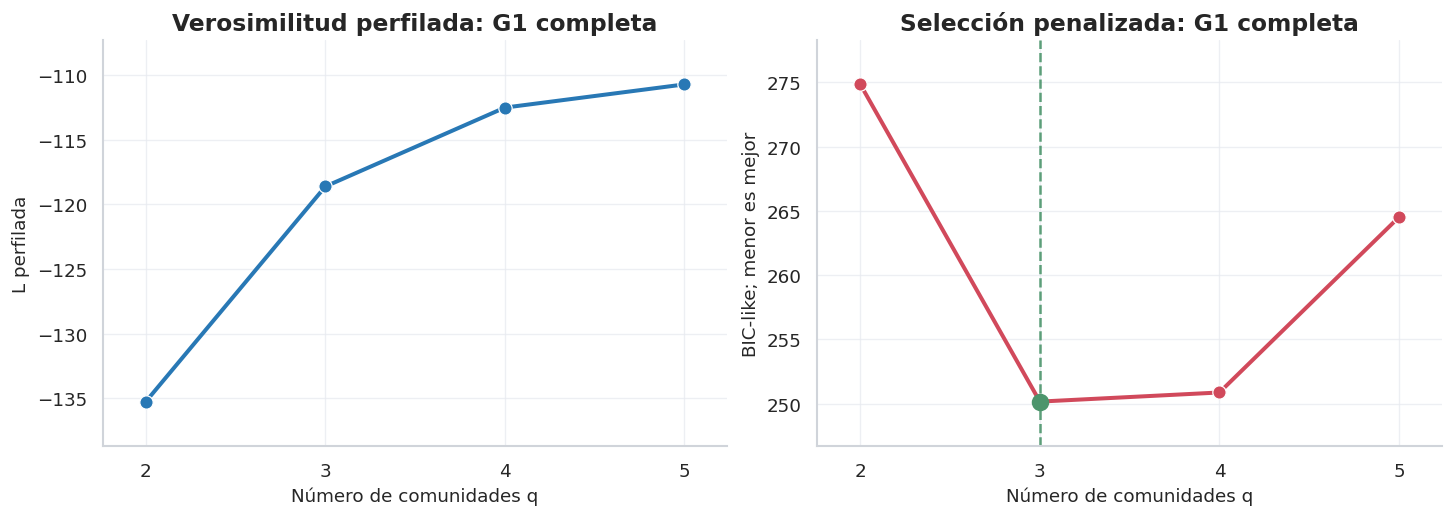

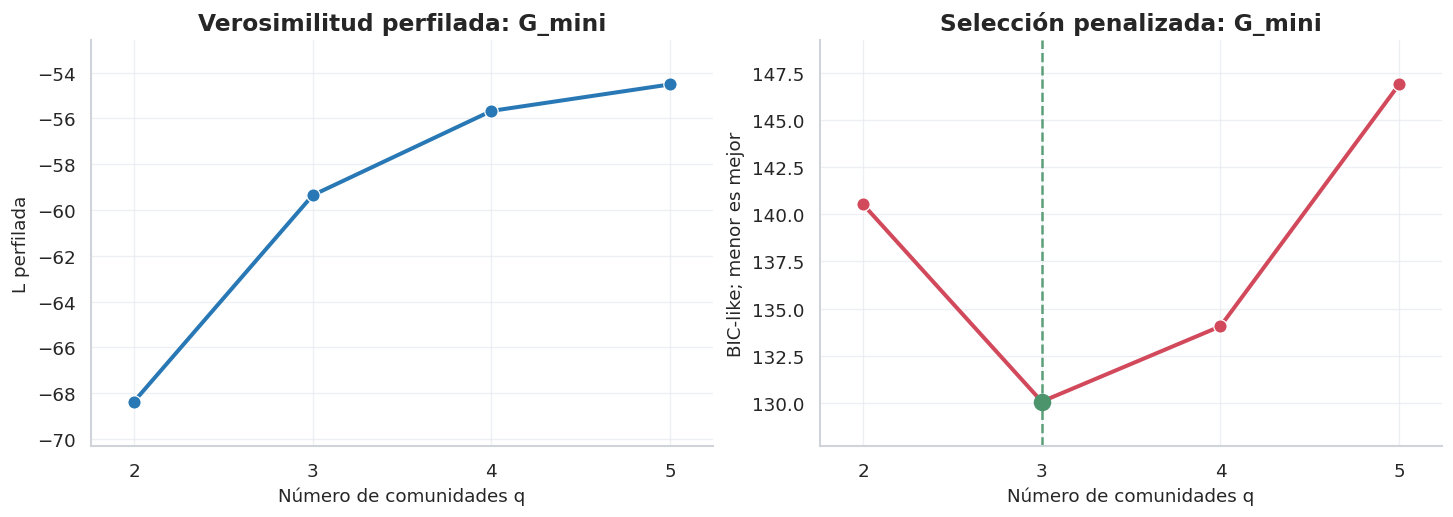

In [7]:
# ============================================================
# 7. Gráfica del barrido de q
# ============================================================
def plot_q_sweep(sweep: pd.DataFrame, graph_name: str) -> None:
    data = sweep[sweep["red"] == graph_name].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)

    sns.lineplot(
        data=data,
        x="q",
        y="L_perfilada",
        marker="o",
        markersize=8,
        linewidth=2.4,
        color="#2878B5",
        ax=axes[0],
    )
    axes[0].set_title(f"Verosimilitud perfilada: {graph_name}")
    axes[0].set_xlabel("Número de comunidades q")
    axes[0].set_ylabel("L perfilada")
    axes[0].set_xticks(data["q"].tolist())

    sns.lineplot(
        data=data,
        x="q",
        y="BIC_like_menor_mejor",
        marker="o",
        markersize=8,
        linewidth=2.4,
        color="#D1495B",
        ax=axes[1],
    )
    best_row = data.loc[data["BIC_like_menor_mejor"].idxmin()]
    axes[1].axvline(best_row["q"], color="#4C956C", linestyle="--", linewidth=1.5, alpha=0.9)
    axes[1].scatter(best_row["q"], best_row["BIC_like_menor_mejor"], s=90, color="#4C956C", zorder=4)
    axes[1].set_title(f"Selección penalizada: {graph_name}")
    axes[1].set_xlabel("Número de comunidades q")
    axes[1].set_ylabel("BIC-like; menor es mejor")
    axes[1].set_xticks(data["q"].tolist())

    for ax in axes:
        ax.grid(True, alpha=0.75)
        ax.margins(x=0.08, y=0.14)
    sns.despine(fig=fig)

    fig.savefig(OUT_DIR / f"barrido_q_{graph_name.replace(' ', '_')}.png", bbox_inches="tight")
    plt.show()

plot_q_sweep(sweep_df, "G1 completa")
plot_q_sweep(sweep_df, "G_mini")


## 6. Resultados de comunidades

La tabla reporta, para cada empresa, su comunidad estimada, grado y componente conexa. Después se muestran dos matrices clave:

$$
M=(m_{rs})
\quad\text{y}\quad
\hat\Omega=(\hat\omega_{rs}).
$$

La matriz $M$ responde: "¿dónde están las aristas observadas?". La matriz $\hat\Omega$ responde algo más estadístico: "¿qué pares de bloques se conectan más de lo esperable dado su volumen de grado?".

La lectura específica del caso es la siguiente:

- En $G_1$, `C0` concentra el subecosistema de consumo, retail y pagos (`AAPL`, `MA`, `V`, `WMT`, `COST`, `HD`, etc.). Tiene 13 aristas internas y ninguna arista hacia los otros bloques, por eso aparece como una comunidad asortativa clara.
- `C1` y `C2` forman la parte tecnológica de la red. No aparecen como comunidades densas internamente: en $M$, sus diagonales son cero. Su estructura relevante está en las 24 unidades de masa entre `C1` y `C2`.
- En $G_{\text{mini}}$ se conserva la misma historia con menos nodos periféricos: `C0` mantiene el núcleo pagos/retail; `C1` agrupa plataformas/compradores tecnológicos (`AMZN`, `MSFT`, `ORCL`, `GOOGL`, `TSLA`); `C2` agrupa infraestructura/IA (`NVDA`, `AMD`, `PLTR`).

In [8]:
# ============================================================
# 8. Tablas de resultados
# ============================================================
def node_partition_table(G: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    component_id = {}
    for idx, comp in enumerate(nx.connected_components(G)):
        for node in comp:
            component_id[node] = idx

    rows = []
    for node in sorted(G.nodes()):
        rows.append({
            "nodo": node,
            "comunidad": f"C{fit.labels[node]}",
            "grado": G.degree(node),
            "componente_conexa": component_id[node],
        })
    return pd.DataFrame(rows).sort_values(["comunidad", "grado", "nodo"], ascending=[True, False, True])


def community_summary_table(G: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    rows = []
    for c, nodes in fit.communities.items():
        sub = G.subgraph(nodes)
        boundary_edges = sum(1 for u, v in G.edges() if (u in nodes) ^ (v in nodes))
        rows.append({
            "comunidad": f"C{c}",
            "nodos": len(nodes),
            "aristas_internas": sub.number_of_edges(),
            "aristas_frontera": boundary_edges,
            "kappa_suma_grados": fit.kappa.loc[f"C{c}"],
            "miembros": ", ".join(nodes),
        })
    return pd.DataFrame(rows)

for name, G, fit in [("G1", G1, fit_full), ("G_mini", G_mini, fit_mini)]:
    print(f"\n==================== {name} ====================")
    print(f"q seleccionado: {fit.q}")
    print(f"L perfilada: {fit.L:.6f}")
    print(f"BIC-like: {fit.bic_like:.6f}")
    print(f"Modularidad diagnóstica: {fit.modularity:.6f}")

    nodes_df = node_partition_table(G, fit)
    comm_df = community_summary_table(G, fit)

    display(Markdown(f"### Partición de nodos: {name}"))
    display(nodes_df)
    display(Markdown(f"### Resumen por comunidad: {name}"))
    display(comm_df)
    display(Markdown(f"### Matriz M=(m_rs): {name}"))
    display(fit.M)
    display(Markdown(f"### Matriz Omega estimada: {name}"))
    display(fit.omega)

    nodes_df.to_csv(OUT_DIR / f"particion_nodos_{name}.csv", index=False)
    comm_df.to_csv(OUT_DIR / f"resumen_comunidades_{name}.csv", index=False)
    fit.M.to_csv(OUT_DIR / f"matriz_M_{name}.csv")
    fit.omega.to_csv(OUT_DIR / f"omega_estimado_{name}.csv")


==================== G1 ====================
q seleccionado: 3
L perfilada: -118.628547
BIC-like: 250.169289
Modularidad diagnóstica: 0.017531


### Partición de nodos: G1

,nodo,comunidad,grado,componente_conexa
0,AAPL,C0,5,0
16,MA,C0,4,0
28,WMT,C0,4,0
27,V,C0,3,0
5,BAC,C0,2,0
7,COST,C0,2,0
12,HD,C0,2,0
4,AVGO,C0,1,0
6,BRK.B,C0,1,0
14,JPM,C0,1,0


### Resumen por comunidad: G1

,comunidad,nodos,aristas_internas,aristas_frontera,kappa_suma_grados,miembros
0,C0,11,13,0,26.0,"AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG,..."
1,C1,11,0,24,24.0,"ABBV, AMD, CVX, GE, JNJ, LLY, NFLX, NVDA, PLTR..."
2,C2,8,0,24,24.0,"AMZN, GOOG, GOOGL, META, MSFT, MU, ORCL, TSLA"


...

,comunidad,nodos,aristas_internas,aristas_frontera,kappa_suma_grados,miembros
0,C0,7,9,0,18.0,"AAPL, BAC, COST, HD, MA, V, WMT"
1,C1,5,0,13,13.0,"AMZN, GOOGL, MSFT, ORCL, TSLA"
2,C2,3,0,13,13.0,"AMD, NVDA, PLTR"


### Matriz M=(m_rs): G_mini

,C0,C1,C2
C0,18.0,0.0,0.0
C1,0.0,0.0,13.0
C2,0.0,13.0,0.0


### Matriz Omega estimada: G_mini

,C0,C1,C2
C0,2.444444,0.000000,0.000000
C1,0.000000,0.000000,3.384615
C2,0.000000,3.384615,0.000000


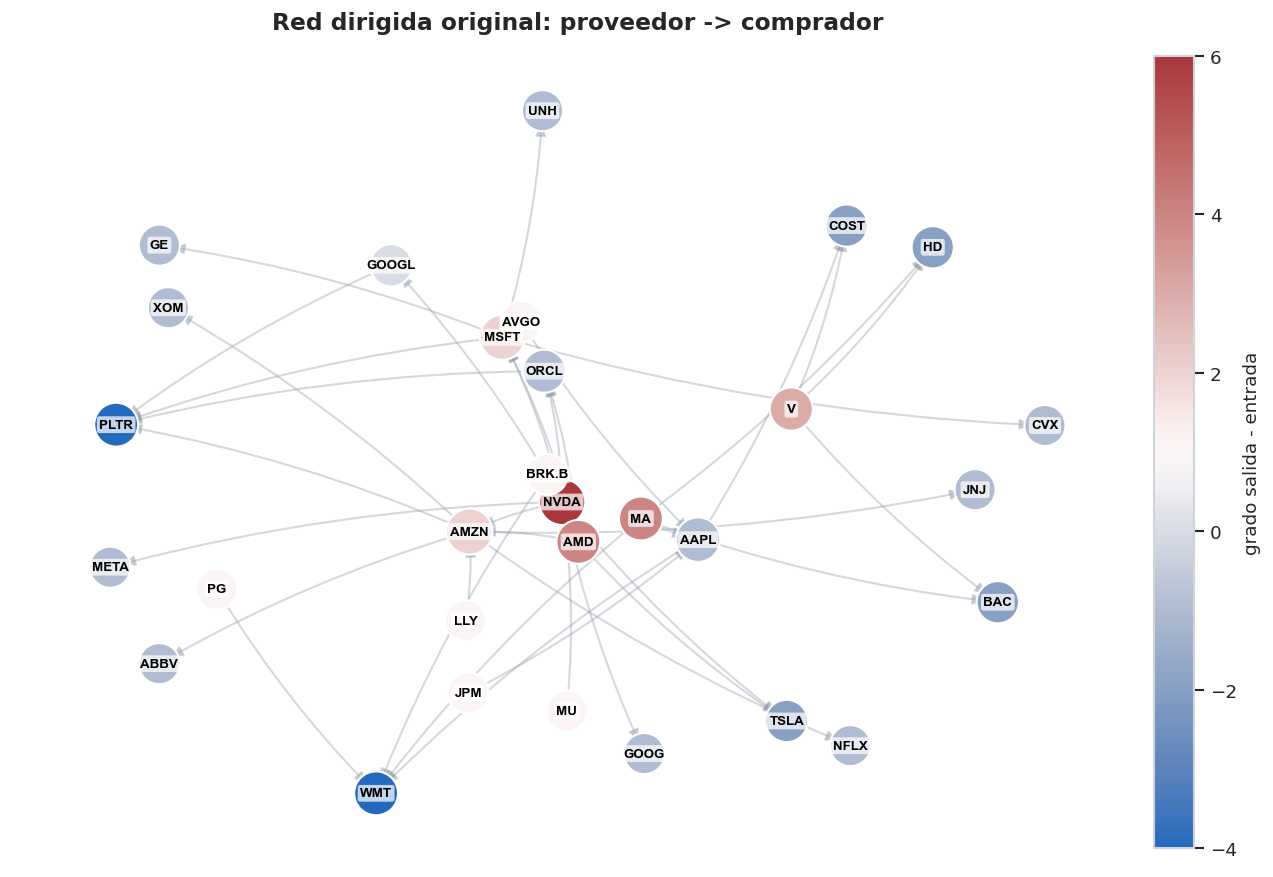

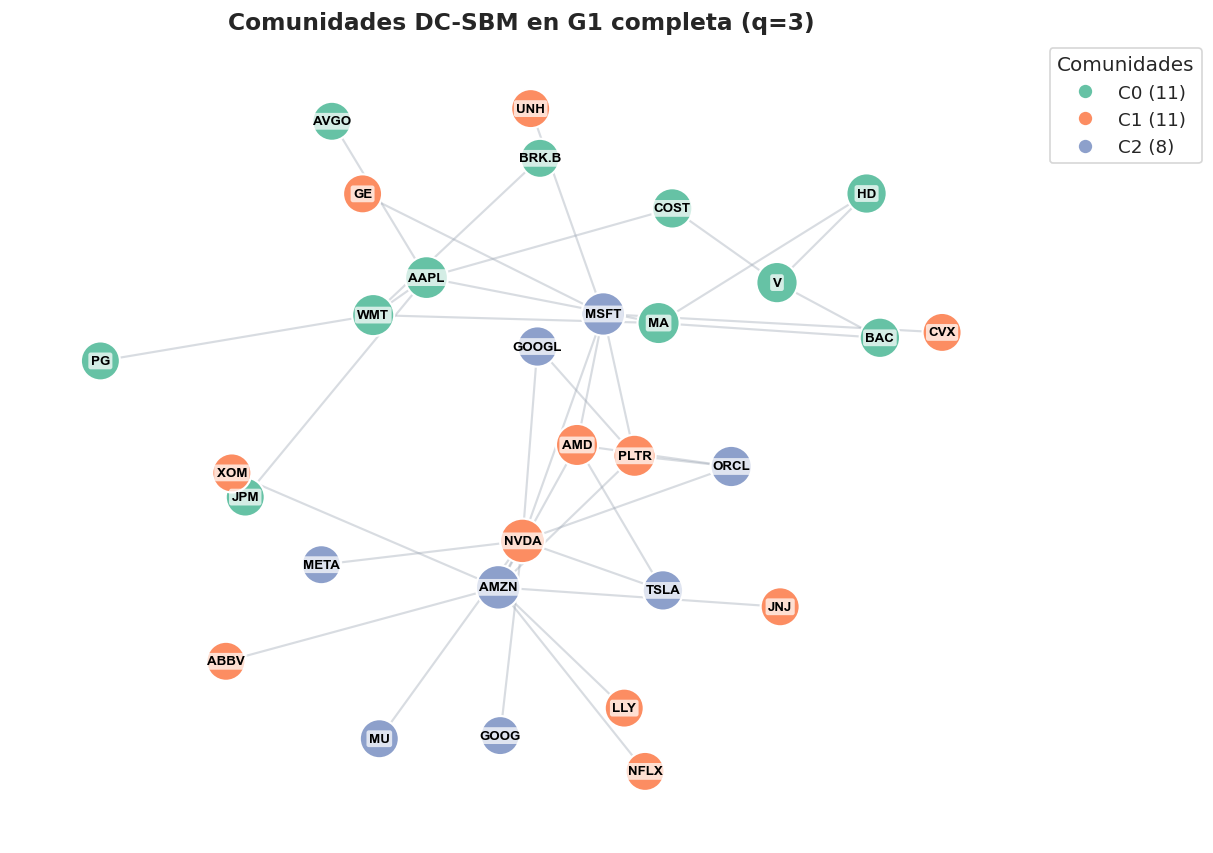

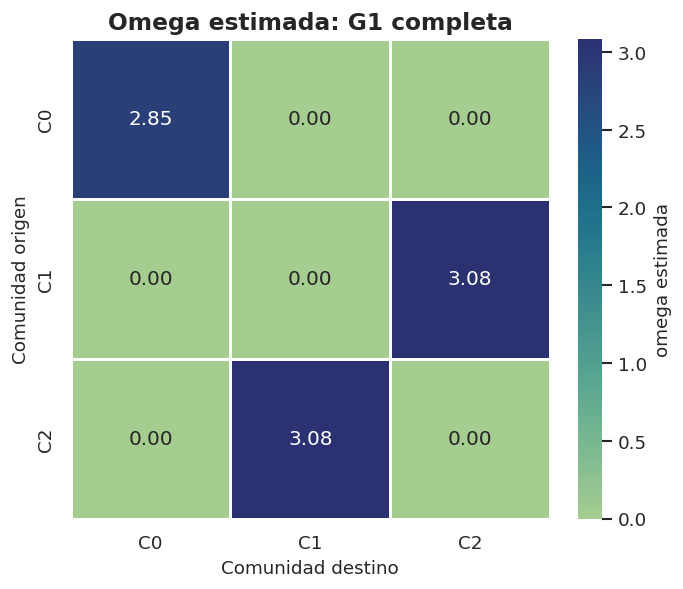

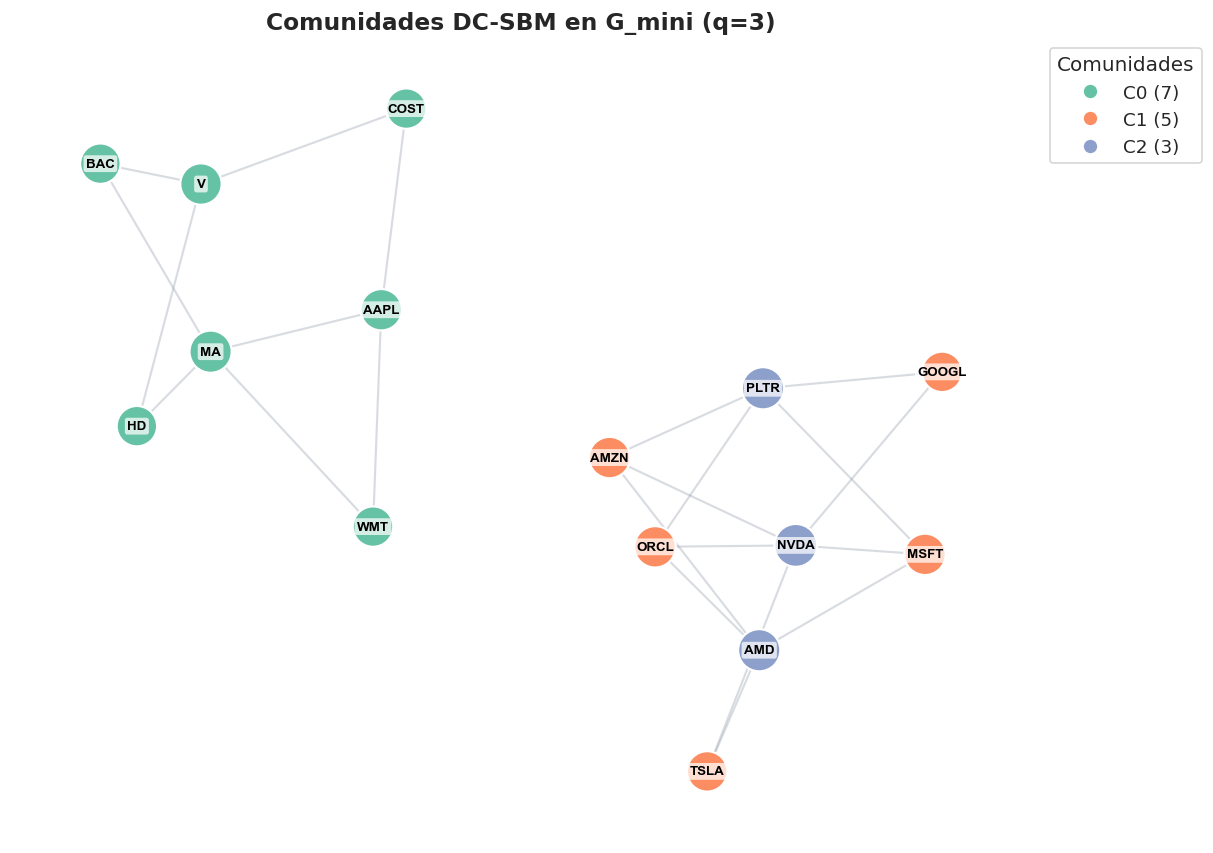

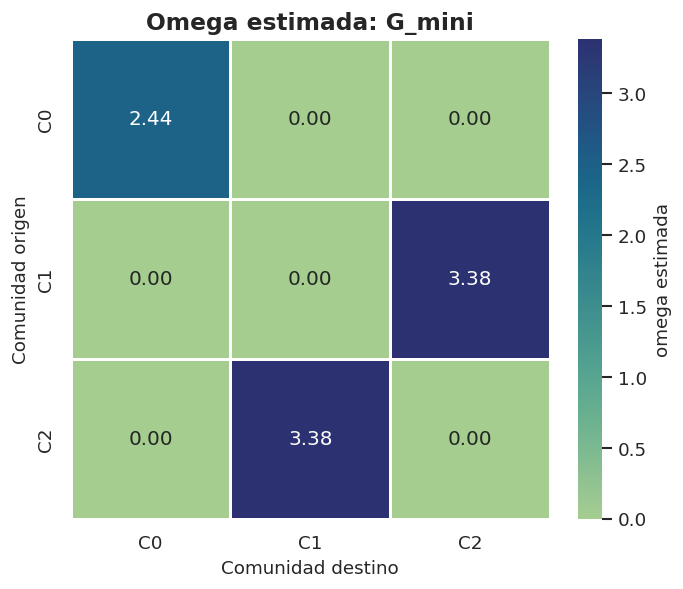

In [9]:
# ============================================================
# 9. Visualización de particiones y matrices omega
# ============================================================
def community_palette(q: int) -> list[tuple[float, float, float]]:
    """Paleta consistente para bloques: Set2 hasta 8; después cambia suavemente a husl."""
    if q <= 8:
        return sns.color_palette("Set2", n_colors=max(q, 3))[:q]
    return sns.color_palette("husl", n_colors=q)


def community_color_map(fit: DCSBMFit) -> dict[int, tuple[float, float, float]]:
    return {community: color for community, color in enumerate(community_palette(fit.q))}


def draw_partition(G: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    labels = fit.labels
    colors = community_color_map(fit)
    node_colors = [colors[labels[node]] for node in G.nodes()]
    node_sizes = [460 + 90 * np.sqrt(G.degree(node)) for node in G.nodes()]
    pos = nx.spring_layout(G, seed=RANDOM_SEED, k=0.75)

    fig, ax = plt.subplots(figsize=(10, 7), constrained_layout=True)
    ax.set_title(title)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#9AA4B2", alpha=0.38, width=1.3)
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        edgecolors="white",
        linewidths=1.3,
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.72},
    )
    handles = [
        Line2D([0], [0], marker="o", color="w", label=f"C{c} ({len(fit.communities[c])})",
               markerfacecolor=colors[c], markeredgecolor="white", markersize=9)
        for c in range(fit.q)
    ]
    ax.legend(handles=handles, title="Comunidades", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
    ax.axis("off")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_omega(fit: DCSBMFit, title: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)
    sns.heatmap(
        fit.omega,
        annot=True,
        fmt=".2f",
        cmap="crest",
        square=True,
        linewidths=0.8,
        linecolor="white",
        cbar_kws={"label": "omega estimada"},
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Comunidad destino")
    ax.set_ylabel("Comunidad origen")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()

# Visualizar red dirigida original solo como referencia.
pos_dir = nx.spring_layout(G_dir, seed=RANDOM_SEED, k=0.75)
out_degree = dict(G_dir.out_degree())
in_degree = dict(G_dir.in_degree())
node_sizes = [520 + 85 * np.sqrt(G_dir.degree(node)) for node in G_dir.nodes()]
node_colors = [out_degree[node] - in_degree[node] for node in G_dir.nodes()]

fig, ax = plt.subplots(figsize=(10.5, 7.2), constrained_layout=True)
nx.draw_networkx_edges(
    G_dir,
    pos_dir,
    ax=ax,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=13,
    edge_color="#8F99A8",
    alpha=0.38,
    width=1.25,
    connectionstyle="arc3,rad=0.06",
)
nodes = nx.draw_networkx_nodes(
    G_dir,
    pos_dir,
    ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap="vlag",
    edgecolors="white",
    linewidths=1.2,
)
nx.draw_networkx_labels(
    G_dir,
    pos_dir,
    ax=ax,
    font_size=8,
    font_weight="bold",
    bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.72},
)
fig.colorbar(nodes, ax=ax, fraction=0.035, pad=0.01, label="grado salida - entrada")
ax.set_title("Red dirigida original: proveedor -> comprador")
ax.axis("off")
fig.savefig(OUT_DIR / "red_dirigida_original.png", bbox_inches="tight")
plt.show()

draw_partition(G1, fit_full, f"Comunidades DC-SBM en G1 completa (q={fit_full.q})", "comunidades_G1.png")
plot_omega(fit_full, "Omega estimada: G1 completa", "omega_G1.png")

draw_partition(G_mini, fit_mini, f"Comunidades DC-SBM en G_mini (q={fit_mini.q})", "comunidades_G_mini.png")
plot_omega(fit_mini, "Omega estimada: G_mini", "omega_G_mini.png")


## 7. Visualizaciones diagnósticas: de la tabla a la intuición

Las tablas anteriores dicen qué bloque recibe cada empresa, pero las imágenes ayudan a ver **por qué** el modelo eligió esa partición.

Las figuras nuevas se leen así:

- **Dashboard de comunidades:** compara tamaño del bloque, volumen de grado $\kappa_r$, aristas internas y aristas de frontera. Sirve para distinguir bloques cerrados de bloques que funcionan como roles.
- **Radiografía de bloques:** muestra $M$, $\hat\Omega$ y la matriz normalizada por fila. Si una fila concentra masa fuera de la diagonal, ese bloque se relaciona principalmente con otro bloque.
- **Adyacencia antes/después:** muestra cómo la misma matriz se vuelve interpretable cuando ordenamos nodos por comunidad. Los bloques diagonales indican estructura asortativa; los rectángulos fuera de diagonal indican estructura disasortativa.
- **Vista bipartita dominante:** enfoca el par de comunidades con mayor $\hat\omega_{rs}$ fuera de la diagonal. En este caso permite ver la separación entre plataformas tecnológicas e infraestructura/IA.

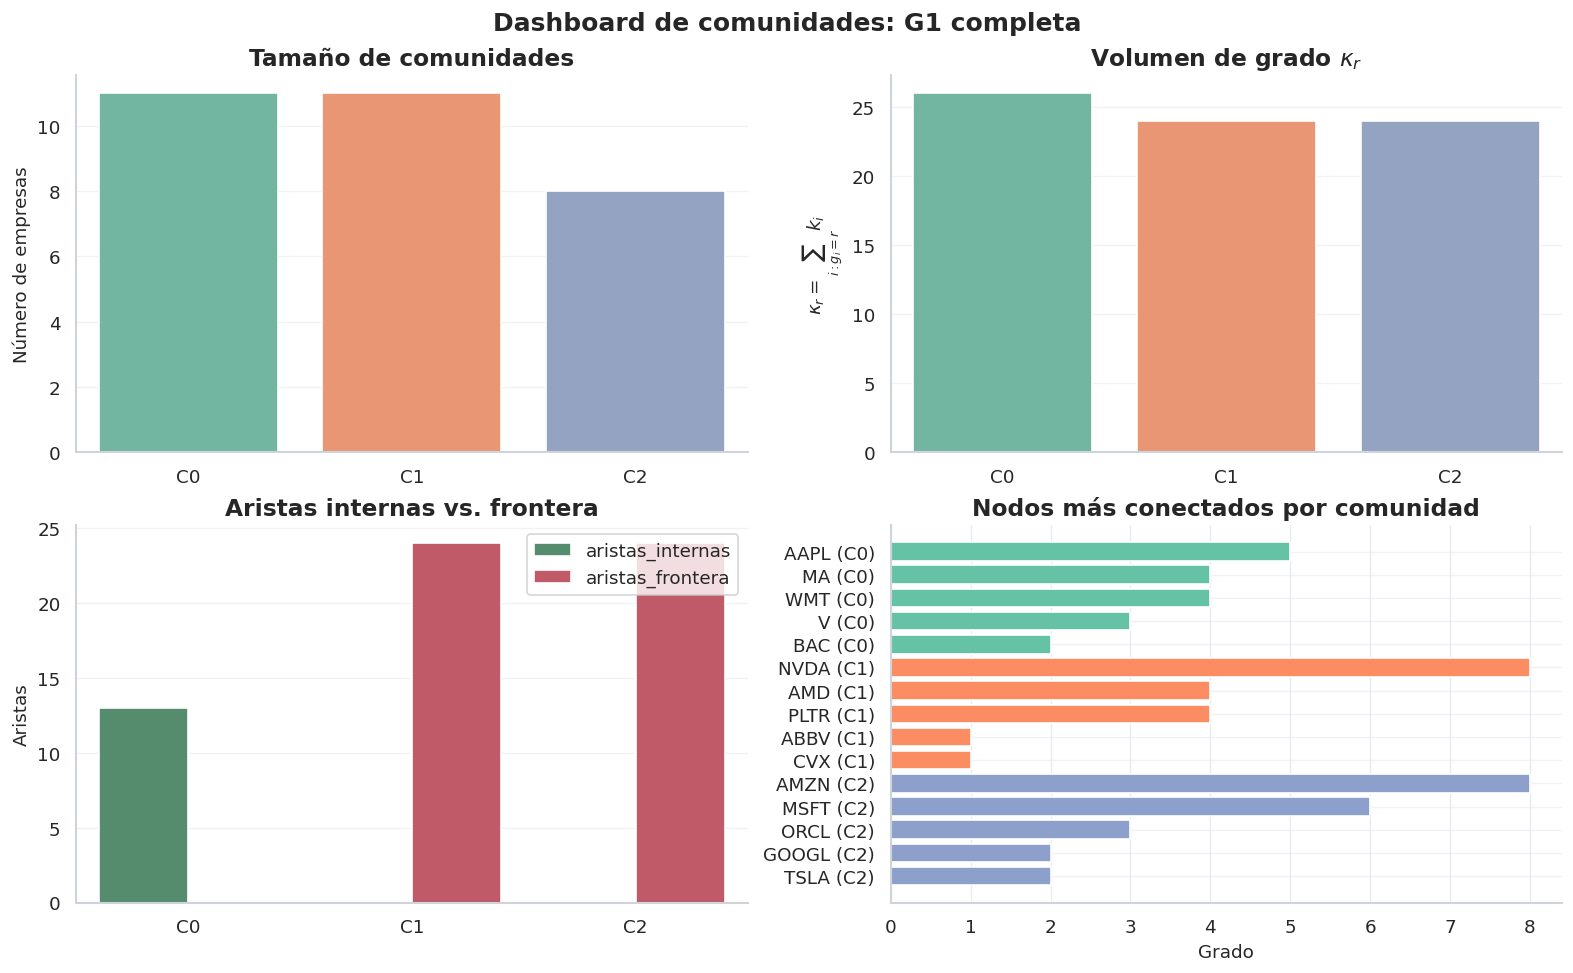

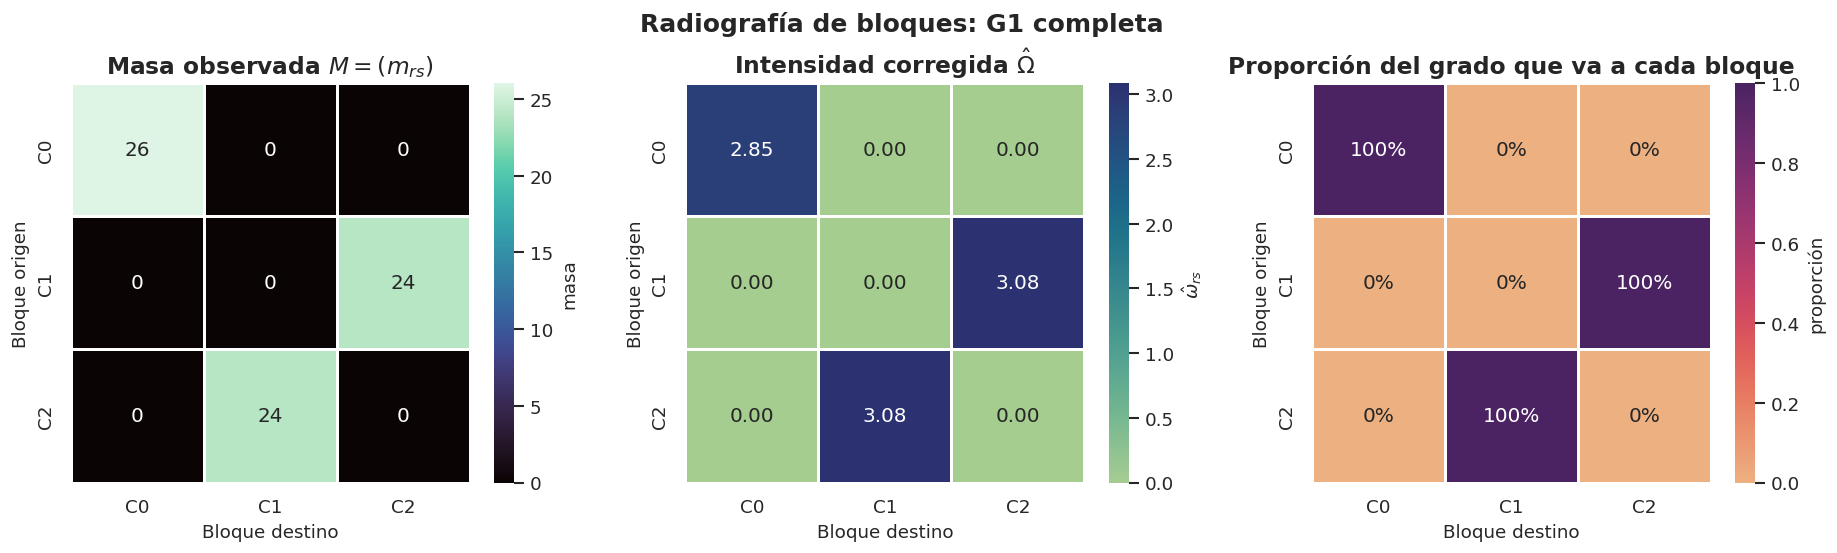

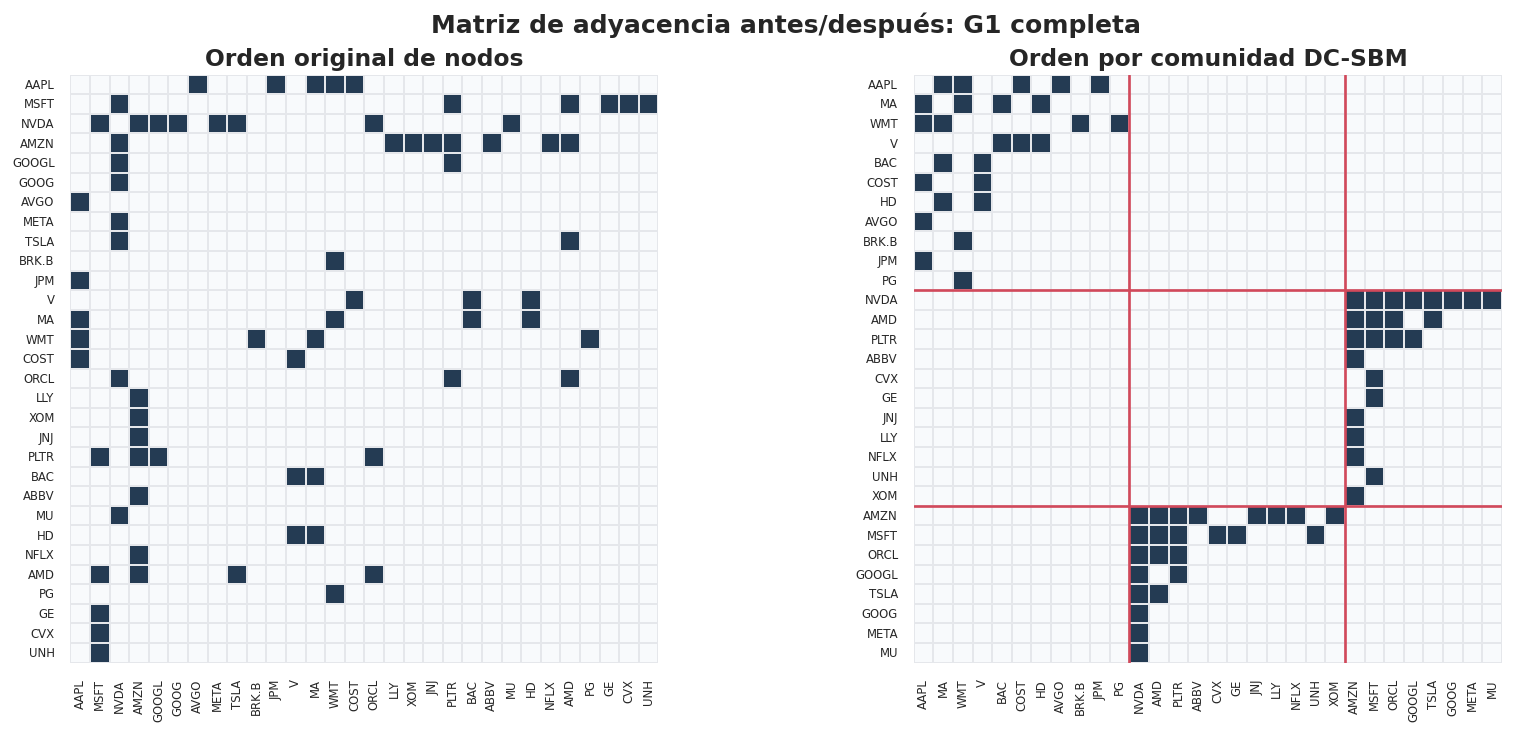

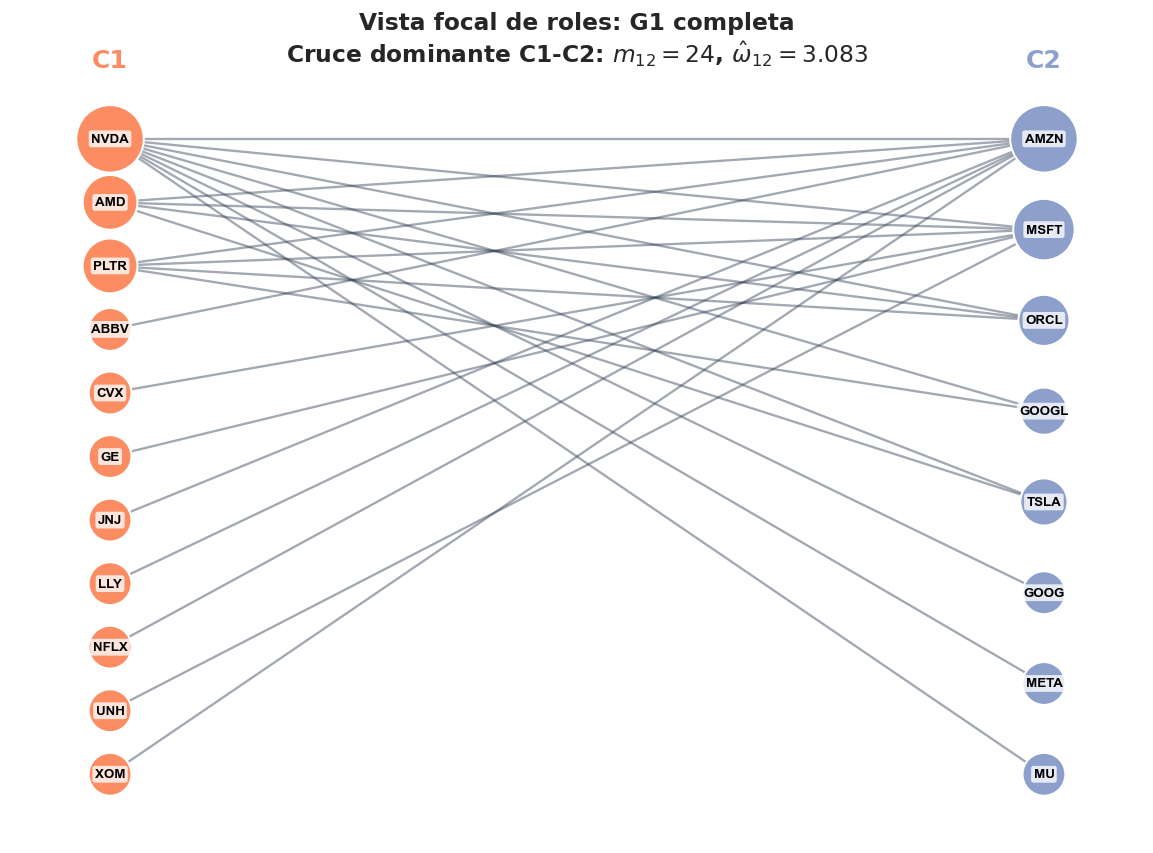

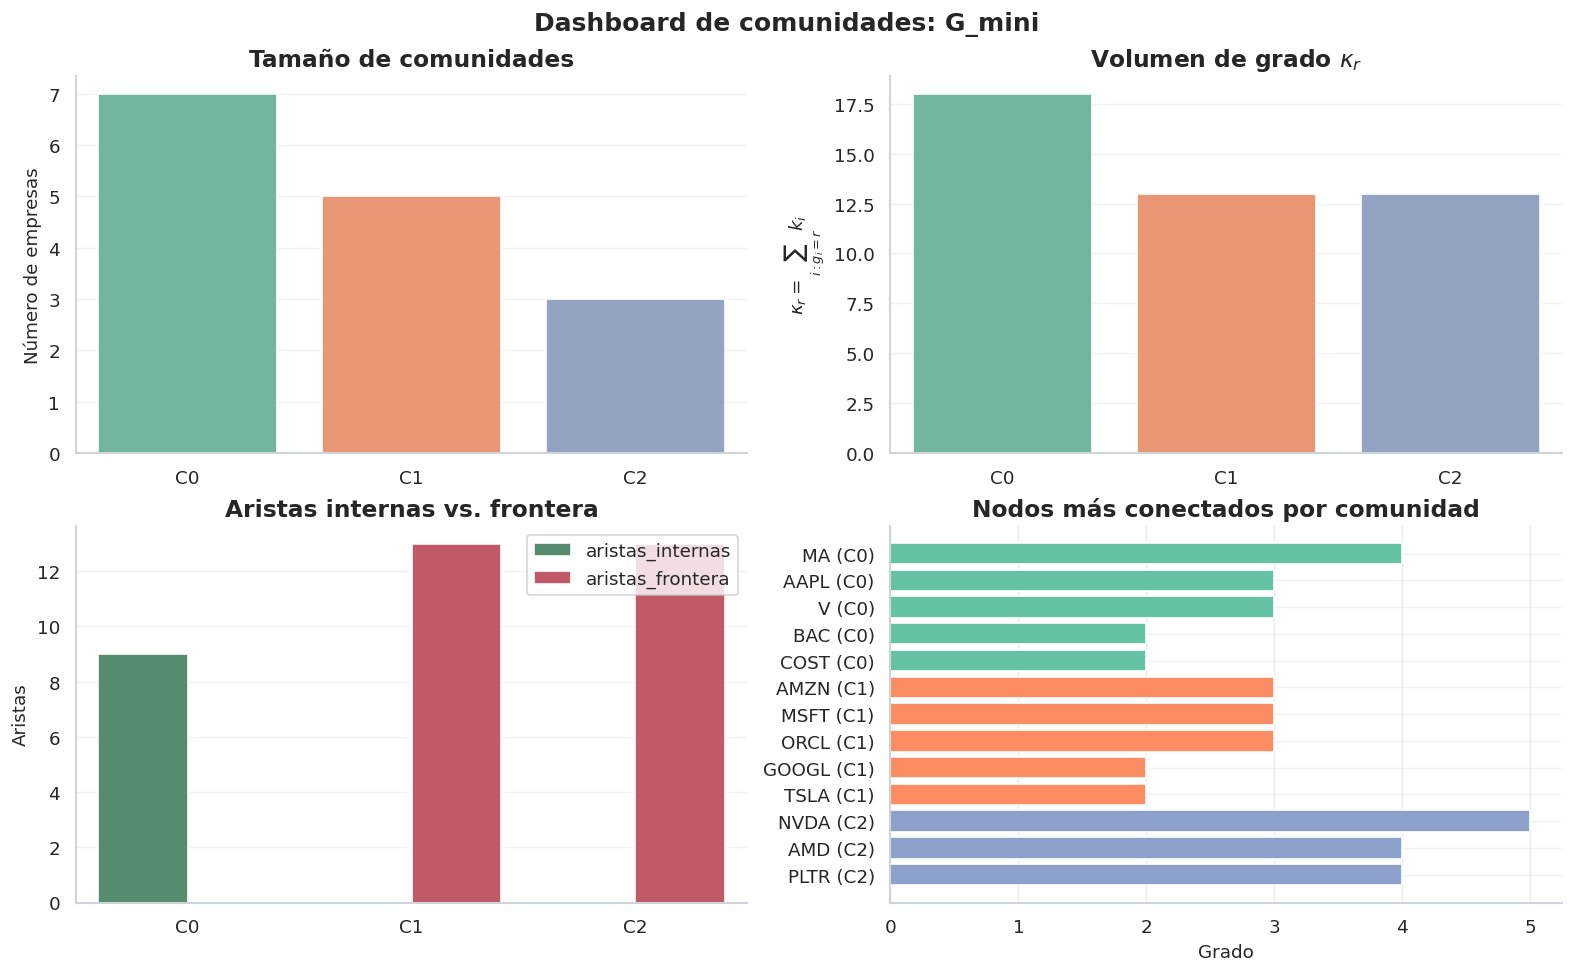

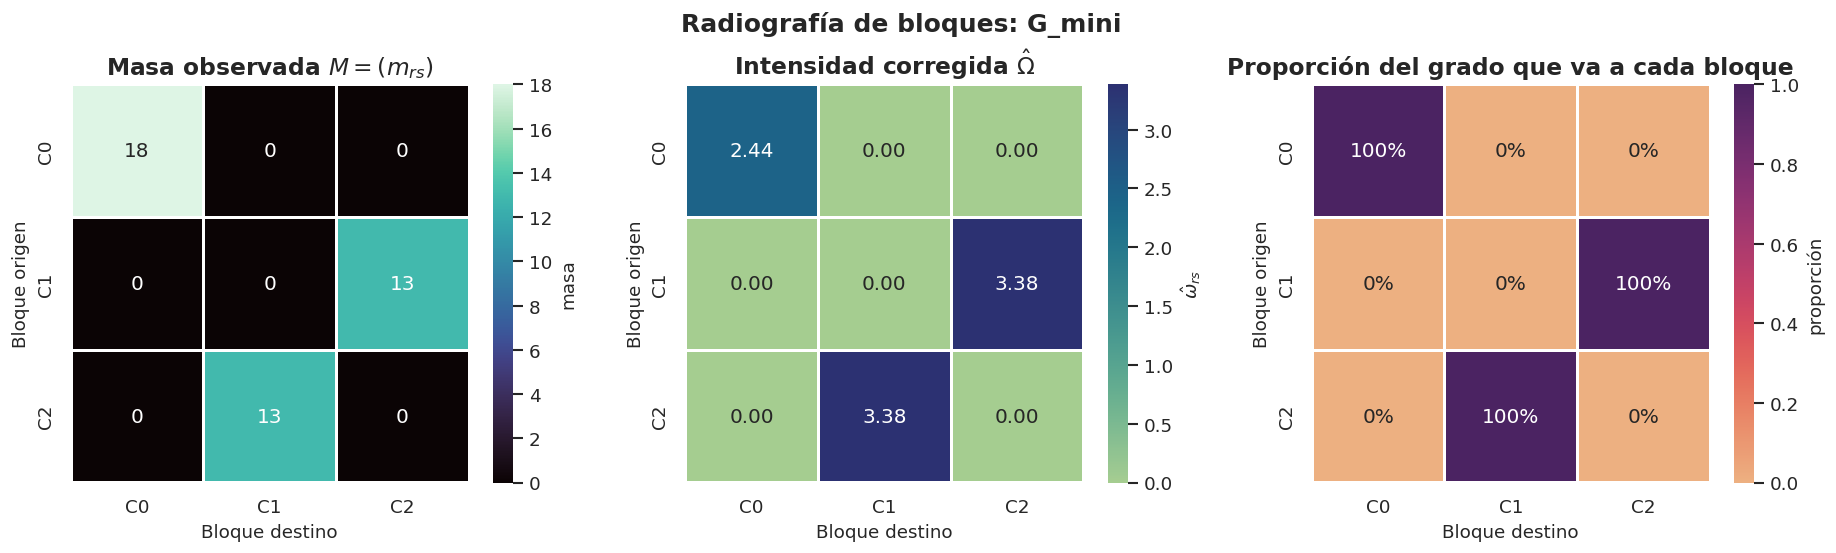

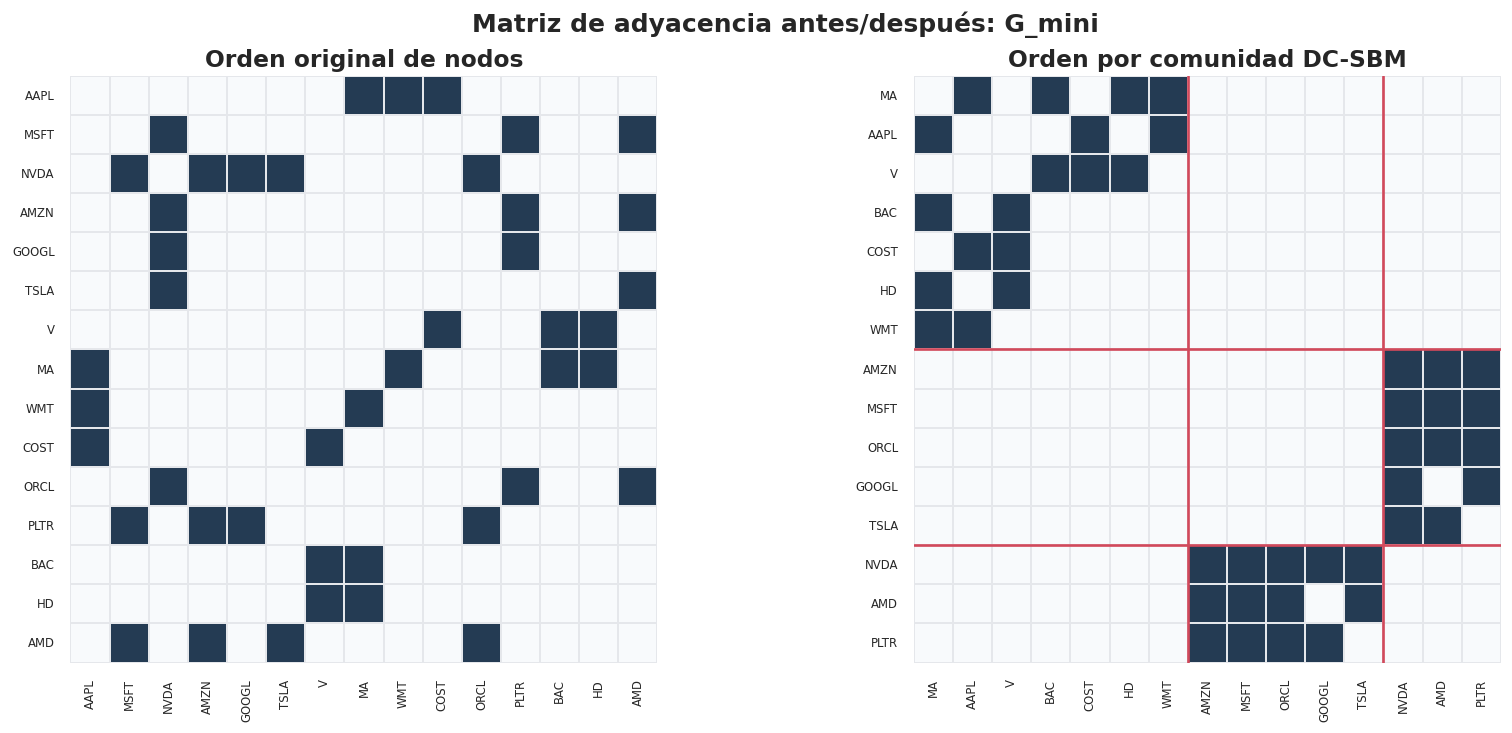

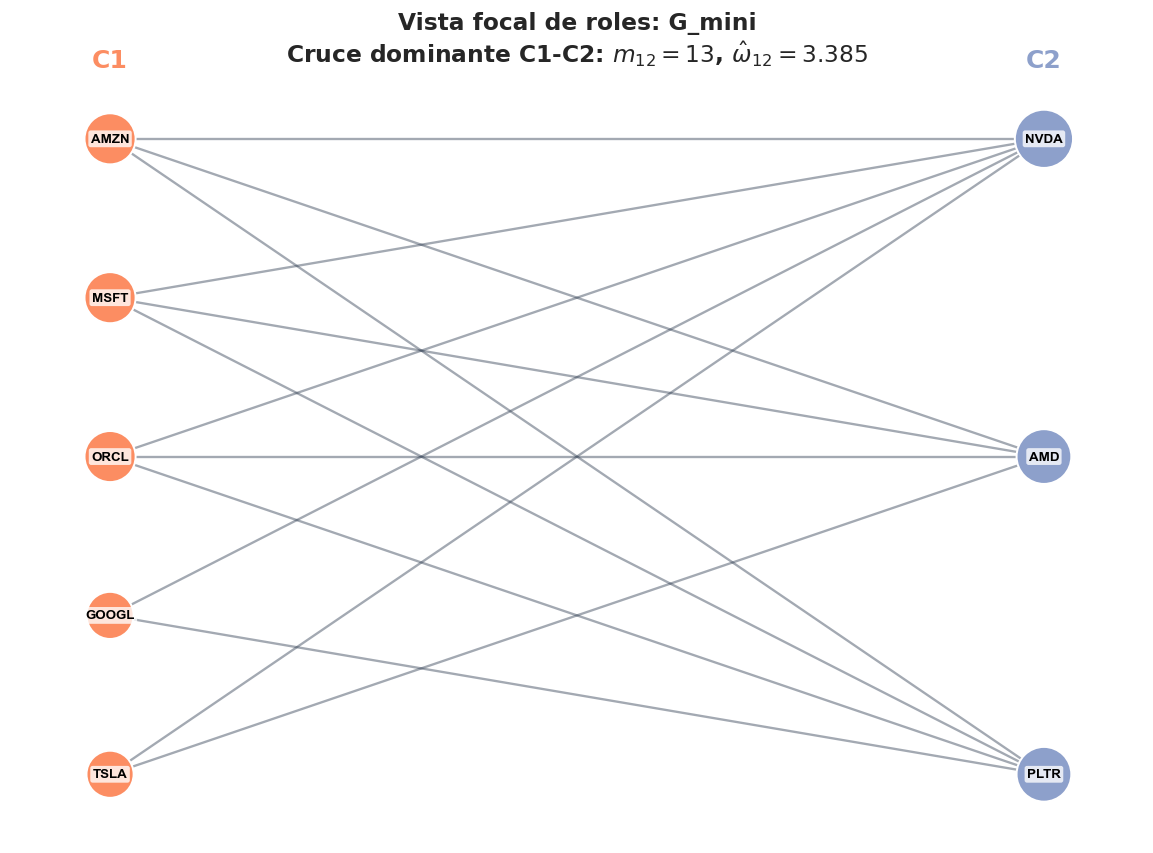

In [10]:
# ============================================================
# 10. Visualizaciones diagnósticas para intuición
# ============================================================
def safe_graph_name(name: str) -> str:
    return name.replace(" ", "_").replace("/", "_")


def ordered_nodes_for_plot(G: nx.Graph, fit: DCSBMFit) -> list[str]:
    ordered = []
    for c in range(fit.q):
        nodes = [node for node in fit.communities[c] if node in G]
        ordered.extend(sorted(nodes, key=lambda node: (-G.degree(node), node)))
    return ordered


def community_diagnostics(G: nx.Graph, fit: DCSBMFit) -> pd.DataFrame:
    rows = []
    for c, nodes in fit.communities.items():
        node_set = set(nodes)
        internal_edges = G.subgraph(nodes).number_of_edges()
        boundary_edges = sum(
            1
            for u, v in G.edges()
            if (u in node_set and v not in node_set) or (v in node_set and u not in node_set)
        )
        rows.append({
            "comunidad": f"C{c}",
            "id": c,
            "nodos": len(nodes),
            "aristas_internas": internal_edges,
            "aristas_frontera": boundary_edges,
            "kappa": float(fit.kappa.iloc[c]),
        })
    return pd.DataFrame(rows)


def plot_community_dashboard(G: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    diag = community_diagnostics(G, fit)
    colors = community_color_map(fit)
    palette = {f"C{c}": colors[c] for c in range(fit.q)}

    fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
    ax_size, ax_kappa, ax_edges, ax_nodes = axes.ravel()

    sns.barplot(data=diag, x="comunidad", y="nodos", hue="comunidad", palette=palette, legend=False, ax=ax_size)
    ax_size.set_title("Tamaño de comunidades")
    ax_size.set_xlabel("")
    ax_size.set_ylabel("Número de empresas")

    sns.barplot(data=diag, x="comunidad", y="kappa", hue="comunidad", palette=palette, legend=False, ax=ax_kappa)
    ax_kappa.set_title(r"Volumen de grado $\kappa_r$")
    ax_kappa.set_xlabel("")
    ax_kappa.set_ylabel(r"$\kappa_r=\sum_{i:g_i=r}k_i$")

    edge_long = diag.melt(
        id_vars=["comunidad"],
        value_vars=["aristas_internas", "aristas_frontera"],
        var_name="tipo",
        value_name="aristas",
    )
    edge_palette = {"aristas_internas": "#4C956C", "aristas_frontera": "#D1495B"}
    sns.barplot(data=edge_long, x="comunidad", y="aristas", hue="tipo", palette=edge_palette, ax=ax_edges)
    ax_edges.set_title("Aristas internas vs. frontera")
    ax_edges.set_xlabel("")
    ax_edges.set_ylabel("Aristas")
    ax_edges.legend(title="", loc="upper right")

    top_rows = []
    for c, nodes in fit.communities.items():
        ranked = sorted([(node, G.degree(node)) for node in nodes], key=lambda x: (-x[1], x[0]))[:5]
        for node, degree in ranked:
            top_rows.append({"nodo": node, "grado": degree, "comunidad": f"C{c}", "id": c})
    top_df = pd.DataFrame(top_rows)
    top_df["etiqueta"] = top_df["nodo"] + " (" + top_df["comunidad"] + ")"
    top_df = top_df.sort_values(["id", "grado", "nodo"], ascending=[True, False, True])
    bar_colors = [palette[c] for c in top_df["comunidad"]]
    ax_nodes.barh(top_df["etiqueta"], top_df["grado"], color=bar_colors)
    ax_nodes.invert_yaxis()
    ax_nodes.set_title("Nodos más conectados por comunidad")
    ax_nodes.set_xlabel("Grado")
    ax_nodes.set_ylabel("")

    for ax in axes.ravel():
        ax.grid(True, axis="y", alpha=0.6)
    sns.despine(fig=fig)
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_block_radiography(fit: DCSBMFit, title: str, filename: str) -> None:
    M = fit.M.copy()
    omega = fit.omega.copy()
    row_share = M.div(M.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

    fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.5), constrained_layout=True)
    specs = [
        (M, "Masa observada $M=(m_{rs})$", ".0f", "mako", "masa"),
        (omega, r"Intensidad corregida $\hat\Omega$", ".2f", "crest", r"$\hat\omega_{rs}$"),
        (row_share, "Proporción del grado que va a cada bloque", ".0%", "flare", "proporción"),
    ]
    for ax, (mat, subtitle, fmt, cmap, cbar_label) in zip(axes, specs):
        sns.heatmap(
            mat,
            annot=True,
            fmt=fmt,
            cmap=cmap,
            square=True,
            linewidths=0.8,
            linecolor="white",
            cbar_kws={"label": cbar_label},
            ax=ax,
        )
        ax.set_title(subtitle)
        ax.set_xlabel("Bloque destino")
        ax.set_ylabel("Bloque origen")
    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def plot_adjacency_before_after(G: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    original_nodes = list(G.nodes())
    ordered_nodes = ordered_nodes_for_plot(G, fit)
    matrices = [
        (nx.to_numpy_array(G, nodelist=original_nodes, dtype=int), original_nodes, "Orden original de nodos"),
        (nx.to_numpy_array(G, nodelist=ordered_nodes, dtype=int), ordered_nodes, "Orden por comunidad DC-SBM"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    cmap = sns.color_palette(["#F8FAFC", "#243B53"], as_cmap=True)
    for ax, (A, nodes, subtitle) in zip(axes, matrices):
        sns.heatmap(
            A,
            ax=ax,
            cmap=cmap,
            cbar=False,
            square=True,
            linewidths=0.12,
            linecolor="#E5E7EB",
            xticklabels=nodes,
            yticklabels=nodes,
        )
        ax.set_title(subtitle)
        ax.tick_params(axis="x", labelrotation=90, labelsize=7)
        ax.tick_params(axis="y", labelsize=7)

    labels = [fit.labels[node] for node in ordered_nodes]
    boundaries = np.cumsum([sum(label == c for label in labels) for c in range(fit.q)])[:-1]
    for boundary in boundaries:
        axes[1].axhline(boundary, color="#D1495B", linewidth=1.6)
        axes[1].axvline(boundary, color="#D1495B", linewidth=1.6)

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


def strongest_cross_pair(fit: DCSBMFit) -> tuple[int, int, float, float]:
    pairs = []
    for r in range(fit.q):
        for s in range(r + 1, fit.q):
            pairs.append((r, s, float(fit.omega.iloc[r, s]), float(fit.M.iloc[r, s])))
    pairs.sort(key=lambda item: (-item[2], -item[3], item[0], item[1]))
    return pairs[0]


def bipartite_role_layout(G: nx.Graph, fit: DCSBMFit, r: int, s: int) -> dict[str, tuple[float, float]]:
    pos = {}
    for x, c in [(-1.7, r), (1.7, s)]:
        nodes = [node for node in fit.communities[c] if node in G]
        nodes = sorted(
            nodes,
            key=lambda node: (
                -sum(1 for nbr in G.neighbors(node) if fit.labels[nbr] != c),
                -G.degree(node),
                node,
            ),
        )
        y_values = np.linspace(1.1, -1.1, len(nodes)) if len(nodes) > 1 else np.array([0.0])
        for node, y in zip(nodes, y_values):
            pos[node] = (x, float(y))
    return pos


def plot_dominant_bipartite_view(G: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    r, s, omega_rs, mass_rs = strongest_cross_pair(fit)
    nodes = [node for node in G.nodes() if fit.labels[node] in {r, s}]
    H = G.subgraph(nodes).copy()
    pos = bipartite_role_layout(G, fit, r, s)
    colors = community_color_map(fit)
    node_colors = [colors[fit.labels[node]] for node in H.nodes()]
    cross_degree = {
        node: sum(1 for nbr in G.neighbors(node) if fit.labels[nbr] != fit.labels[node])
        for node in H.nodes()
    }
    node_sizes = [520 + 140 * cross_degree[node] for node in H.nodes()]
    cross_edges = [(u, v) for u, v in H.edges() if fit.labels[u] != fit.labels[v]]
    internal_edges = [(u, v) for u, v in H.edges() if fit.labels[u] == fit.labels[v]]

    fig, ax = plt.subplots(figsize=(9.5, 7), constrained_layout=True)
    nx.draw_networkx_edges(H, pos, edgelist=internal_edges, ax=ax, edge_color="#CBD5E1", alpha=0.35, width=1.2)
    nx.draw_networkx_edges(H, pos, edgelist=cross_edges, ax=ax, edge_color="#334155", alpha=0.45, width=1.4)
    nx.draw_networkx_nodes(
        H,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="white",
        linewidths=1.2,
    )
    nx.draw_networkx_labels(
        H,
        pos,
        ax=ax,
        font_size=8,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.78},
    )
    ax.text(-1.7, 1.35, f"C{r}", color=colors[r], fontsize=15, fontweight="bold", ha="center")
    ax.text(1.7, 1.35, f"C{s}", color=colors[s], fontsize=15, fontweight="bold", ha="center")
    ax.set_title(
        f"{title}\nCruce dominante C{r}-C{s}: "
        + rf"$m_{{{r}{s}}}={mass_rs:.0f}$, $\hat\omega_{{{r}{s}}}={omega_rs:.3f}$"
    )
    ax.axis("off")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


for G, fit in [(G1, fit_full), (G_mini, fit_mini)]:
    safe = safe_graph_name(fit.graph_name)
    plot_community_dashboard(
        G,
        fit,
        f"Dashboard de comunidades: {fit.graph_name}",
        f"dashboard_comunidades_{safe}.png",
    )
    plot_block_radiography(
        fit,
        f"Radiografía de bloques: {fit.graph_name}",
        f"radiografia_bloques_{safe}.png",
    )
    plot_adjacency_before_after(
        G,
        fit,
        f"Matriz de adyacencia antes/después: {fit.graph_name}",
        f"adyacencia_antes_despues_{safe}.png",
    )
    plot_dominant_bipartite_view(
        G,
        fit,
        f"Vista focal de roles: {fit.graph_name}",
        f"vista_bipartita_dominante_{safe}.png",
    )


## 8. Interpretación sustantiva

La salida automática siguiente ya no debe leerse como un resumen genérico, sino como diagnóstico del caso. Usamos tres niveles:

1. **Selección de escala:** el criterio penalizado elige $q=3$ en ambas redes.
2. **Tipo de estructura:** comparamos la diagonal de $\hat\Omega$ contra los términos fuera de diagonal.
3. **Contenido económico:** revisamos qué empresas caen en cada bloque y qué papel cumple cada bloque.

Un punto importante: una comunidad SBM no siempre significa "grupo denso". En modelos de bloques, una partición también puede descubrir **roles**. Si $\hat\omega_{rs}$ es grande para $r\neq s$ y $\hat\omega_{rr}$ es bajo, el modelo está diciendo que dos bloques se explican mejor como polos de una relación bipartita o complementaria.

In [11]:
# ============================================================
# 10. Interpretación automática
# ============================================================
def dominant_block_pairs(fit: DCSBMFit, top_n: int = 3) -> list[tuple[str, str, float, float]]:
    pairs = []
    for i, row in enumerate(fit.omega.index):
        for j, col in enumerate(fit.omega.columns):
            if i <= j:
                pairs.append((row, col, float(fit.omega.iloc[i, j]), float(fit.M.iloc[i, j])))
    pairs.sort(key=lambda item: (-item[2], -item[3], item[0], item[1]))
    return pairs[:top_n]


def bridge_nodes_between_blocks(G: nx.Graph, fit: DCSBMFit, r: int, s: int, top_n: int = 6) -> list[str]:
    scores = []
    for node in G.nodes():
        label = fit.labels[node]
        if label not in {r, s}:
            continue
        cross_degree = sum(1 for nbr in G.neighbors(node) if fit.labels[nbr] != label)
        if cross_degree:
            scores.append((node, cross_degree, G.degree(node)))
    scores.sort(key=lambda x: (-x[1], -x[2], x[0]))
    return [f"{node}({cross}; grado {degree})" for node, cross, degree in scores[:top_n]]


def interpret_fit(G: nx.Graph, fit: DCSBMFit) -> str:
    omega = fit.omega.values
    diag = np.diag(omega)
    off = omega[~np.eye(fit.q, dtype=bool)]
    mean_diag = float(np.mean(diag)) if len(diag) else np.nan
    mean_off = float(np.mean(off)) if len(off) else np.nan
    ratio = mean_diag / mean_off if mean_off > 0 else np.inf

    lines = []
    lines.append(f"### Interpretación específica: {fit.graph_name}")
    lines.append(f"- El criterio penalizado seleccionó $q={fit.q}$ con $L={fit.L:.4f}$ y BIC-like={fit.bic_like:.4f}.")
    lines.append(f"- La modularidad diagnóstica es baja ($Q={fit.modularity:.4f}$), lo cual es coherente con un SBM que detecta roles además de comunidades densas.")
    lines.append(f"- Media diagonal de $\\hat\\Omega$: {mean_diag:.3f}; media fuera de diagonal: {mean_off:.3f}; razón diagonal/fuera={ratio:.3f}.")

    top_pairs = dominant_block_pairs(fit, top_n=3)
    formatted_pairs = ", ".join(f"{a}-{b}: omega={omega_val:.3f}, M={mass:.0f}" for a, b, omega_val, mass in top_pairs)
    lines.append(f"- Pares de bloques más intensos después de corregir por grado: {formatted_pairs}.")

    if fit.graph_name == "G1 completa":
        lines.append("- En la red completa, `C0` separa el subecosistema pagos/retail/consumo: tiene aristas internas y no se conecta con el componente tecnológico.")
        lines.append("- `C1` y `C2` no son comunidades densas internamente; son dos lados de una estructura tecnológica disasortativa. La masa relevante está entre ambos bloques, no en sus diagonales.")
    elif fit.graph_name == "G_mini":
        lines.append("- En la minired, el patrón se vuelve más nítido: `C0` conserva el núcleo pagos/retail, mientras `C1` y `C2` separan plataformas tecnológicas e infraestructura/IA.")
        lines.append("- La eliminación de nodos hoja no cambia la historia principal; reduce ruido periférico y deja el patrón bipartito tecnológico más visible.")

    for c, nodes in fit.communities.items():
        sub = G.subgraph(nodes)
        members = ", ".join(nodes)
        top_degrees = sorted([(node, G.degree(node)) for node in nodes], key=lambda x: (-x[1], x[0]))[:4]
        role_hint = ""
        member_set = set(nodes)
        if {"AAPL", "MA", "V", "WMT"} & member_set:
            role_hint = " Lectura: bloque de pagos/retail/consumo."
        elif {"NVDA", "AMD", "PLTR"} & member_set:
            role_hint = " Lectura: bloque de infraestructura/IA y nodos conectados a plataformas."
        elif {"AMZN", "MSFT", "ORCL", "GOOGL", "TSLA"} & member_set:
            role_hint = " Lectura: bloque de plataformas/compradores tecnológicos."

        lines.append(
            f"- C{c}: {len(nodes)} nodos; {sub.number_of_edges()} aristas internas; "
            f"$\\kappa_{c}={fit.kappa.iloc[c]:.0f}$. "
            f"Nodos principales por grado: " + ", ".join(f"{node}({deg})" for node, deg in top_degrees) + "."
            + role_hint
        )
        lines.append(f"  Miembros: {members}.")

    # Reportar los puentes del par fuera de diagonal dominante.
    off_pairs = []
    for r in range(fit.q):
        for s in range(r + 1, fit.q):
            off_pairs.append((r, s, float(fit.omega.iloc[r, s]), float(fit.M.iloc[r, s])))
    off_pairs.sort(key=lambda item: (-item[2], -item[3]))
    if off_pairs and off_pairs[0][2] > 0:
        r, s, omega_rs, mass_rs = off_pairs[0]
        bridges = bridge_nodes_between_blocks(G, fit, r, s)
        lines.append(
            f"- El vínculo entre bloques más relevante es C{r}-C{s}: "
            f"$m_{{{r}{s}}}={mass_rs:.0f}$ y $\\hat\\omega_{{{r}{s}}}={omega_rs:.3f}$. "
            f"Nodos que más explican ese cruce: {', '.join(bridges)}."
        )

    return "\n".join(lines)

for G, fit in [(G1, fit_full), (G_mini, fit_mini)]:
    text = interpret_fit(G, fit)
    display(Markdown(text))
    with open(OUT_DIR / f"interpretacion_{fit.graph_name.replace(' ', '_')}.md", "w", encoding="utf-8") as f:
        f.write(text)


### Interpretación específica: G1 completa
- El criterio penalizado seleccionó $q=3$ con $L=-118.6285$ y BIC-like=250.1693.
- La modularidad diagnóstica es baja ($Q=0.0175$), lo cual es coherente con un SBM que detecta roles además de comunidades densas.
- Media diagonal de $\hat\Omega$: 0.949; media fuera de diagonal: 1.028; razón diagonal/fuera=0.923.
- Pares de bloques más intensos después de corregir por grado: C1-C2: omega=3.083, M=24, C0-C0: omega=2.846, M=26, C0-C1: omega=0.000, M=0.
- En la red completa, `C0` separa el subecosistema pagos/retail/consumo: tiene aristas internas y no se conecta con el componente tecnológico.
- `C1` y `C2` no son comunidades densas internamente; son dos lados de una estructura tecnológica disasortativa. La masa relevante está entre ambos bloques, no en sus diagonales.
- C0: 11 nodos; 13 aristas internas; $\kappa_0=26$. Nodos principales por grado: AAPL(5), MA(4), WMT(4), V(3). Lectura: bloque de pagos/retail/consumo.
  Miembros: AAPL, AVGO, BAC, BRK.B, COST, HD, JPM, MA, PG, V, WMT.
- C1: 11 nodos; 0 aristas internas; $\kappa_1=24$. Nodos principales por grado: NVDA(8), AMD(4), PLTR(4), ABBV(1). Lectura: bloque de infraestructura/IA y nodos conectados a plataformas.
  Miembros: ABBV, AMD, CVX, GE, JNJ, LLY, NFLX, NVDA, PLTR, UNH, XOM.
- C2: 8 nodos; 0 aristas internas; $\kappa_2=24$. Nodos principales por grado: AMZN(8), MSFT(6), ORCL(3), GOOGL(2). Lectura: bloque de plataformas/compradores tecnológicos.
  Miembros: AMZN, GOOG, GOOGL, META, MSFT, MU, ORCL, TSLA.
- El vínculo entre bloques más relevante es C1-C2: $m_{12}=24$ y $\hat\omega_{12}=3.083$. Nodos que más explican ese cruce: AMZN(8; grado 8), NVDA(8; grado 8), MSFT(6; grado 6), AMD(4; grado 4), PLTR(4; grado 4), ORCL(3; grado 3).

### Interpretación específica: G_mini
- El criterio penalizado seleccionó $q=3$ con $L=-59.3577$ y BIC-like=130.0679.
- La modularidad diagnóstica es baja ($Q=0.0671$), lo cual es coherente con un SBM que detecta roles además de comunidades densas.
- Media diagonal de $\hat\Omega$: 0.815; media fuera de diagonal: 1.128; razón diagonal/fuera=0.722.
- Pares de bloques más intensos después de corregir por grado: C1-C2: omega=3.385, M=13, C0-C0: omega=2.444, M=18, C0-C1: omega=0.000, M=0.
- En la minired, el patrón se vuelve más nítido: `C0` conserva el núcleo pagos/retail, mientras `C1` y `C2` separan plataformas tecnológicas e infraestructura/IA.
- La eliminación de nodos hoja no cambia la historia principal; reduce ruido periférico y deja el patrón bipartito tecnológico más visible.
- C0: 7 nodos; 9 aristas internas; $\kappa_0=18$. Nodos principales por grado: MA(4), AAPL(3), V(3), BAC(2). Lectura: bloque de pagos/retail/consumo.
  Miembros: AAPL, BAC, COST, HD, MA, V, WMT.
- C1: 5 nodos; 0 aristas internas; $\kappa_1=13$. Nodos principales por grado: AMZN(3), MSFT(3), ORCL(3), GOOGL(2). Lectura: bloque de plataformas/compradores tecnológicos.
  Miembros: AMZN, GOOGL, MSFT, ORCL, TSLA.
- C2: 3 nodos; 0 aristas internas; $\kappa_2=13$. Nodos principales por grado: NVDA(5), AMD(4), PLTR(4). Lectura: bloque de infraestructura/IA y nodos conectados a plataformas.
  Miembros: AMD, NVDA, PLTR.
- El vínculo entre bloques más relevante es C1-C2: $m_{12}=13$ y $\hat\omega_{12}=3.385$. Nodos que más explican ese cruce: NVDA(5; grado 5), AMD(4; grado 4), PLTR(4; grado 4), AMZN(3; grado 3), MSFT(3; grado 3), ORCL(3; grado 3).

## 9. Validación por sensibilidad

El algoritmo usa una heurística de máximo local. Por eso, en redes pequeñas, conviene revisar si la partición cambia cuando aumentamos el número de arranques o cuando modificamos el conjunto de nodos.

La prueba opcional compara:

$$
\max_{\text{arranques}} L(g)
$$

para un número mayor de inicializaciones. Si el mejor valor de $L$ se mantiene estable y la composición de comunidades no cambia sustantivamente, la lectura del caso es más confiable.

En esta notebook se deja apagada por defecto para que la ejecución sea rápida en clase.

In [12]:
# ============================================================
# 11. Sensibilidad opcional
# ============================================================
RUN_SENSITIVITY = False

if RUN_SENSITIVITY:
    for n_starts in [100, 250, 500, 1000]:
        fit_test = fit_dc_sbm(G1, "G1 completa", q=best_q_full, n_starts=n_starts, seed=RANDOM_SEED + n_starts)
        print(f"n_starts={n_starts:4d} | L={fit_test.L:.6f} | modularidad={fit_test.modularity:.6f}")
else:
    print("Sensibilidad no ejecutada. Cambia RUN_SENSITIVITY=True para correrla.")

Sensibilidad no ejecutada. Cambia RUN_SENSITIVITY=True para correrla.


## 10. Conclusión del caso

El DC-SBM separa la red en tres bloques con una interpretación económica clara.

En la red completa, `C0` es un bloque asortativo de consumo, pagos y retail. Sus aristas están dentro del bloque:

$$
m_{00}=26,\qquad \hat\omega_{00}=2.846.
$$

Esto significa que, después de corregir por grado, ese grupo está más conectado internamente que lo esperable bajo una mezcla aleatoria con los mismos grados.

La parte tecnológica no se comporta como una sola comunidad densa. El modelo la parte en dos roles complementarios:

$$
m_{12}=m_{21}=24,\qquad
\hat\omega_{12}=\hat\omega_{21}=3.083,
\qquad
m_{11}=m_{22}=0.
$$

Es decir, el patrón dominante no es "empresas tecnológicas conectadas entre sí", sino una relación entre dos lados: por un lado infraestructura/IA y nodos periféricos asociados (`NVDA`, `AMD`, `PLTR`, junto con empresas conectadas a plataformas), y por otro plataformas/compradores tecnológicos (`AMZN`, `MSFT`, `ORCL`, `GOOGL`, `TSLA`, etc.).

La minired refuerza esta interpretación. Al retirar hojas, queda un núcleo con:

$$
m_{00}=18,\qquad
m_{12}=m_{21}=13,\qquad
\hat\omega_{12}=3.385.
$$

Así, el resultado principal del caso no es solo que $q=3$ sea conveniente, sino que la red mezcla dos formas de organización: una comunidad cerrada de pagos/retail y una estructura disasortativa tecnológica de roles complementarios.

$$
\boxed{
\hat g
=\arg\max_g\;
\frac12\sum_{r,s}m_{rs}\log\left(\frac{m_{rs}}{\kappa_r\kappa_s}\right)
}
$$

## 11. Visualización final: matriz de adyacencia y red partida

La figura final une dos vistas complementarias del mismo ajuste.

En la matriz de adyacencia, los nodos están ordenados por comunidad. Si una comunidad es asortativa, aparecen bloques oscuros sobre la diagonal. Si la estructura es disasortativa, aparecen rectángulos fuera de la diagonal.

En la red partida, los nodos se colocan en columnas por comunidad. Las aristas sólidas muestran conexiones internas al bloque y las aristas punteadas muestran conexiones entre bloques. Para este caso, la visualización debe mostrar:

- un bloque `C0` relativamente cerrado en pagos/retail;
- dos bloques tecnológicos conectados principalmente entre sí, no dentro de sí mismos;
- la misma partición en $G_1$ y en $G_{\text{mini}}$, con la minired eliminando nodos periféricos pero conservando la estructura central.

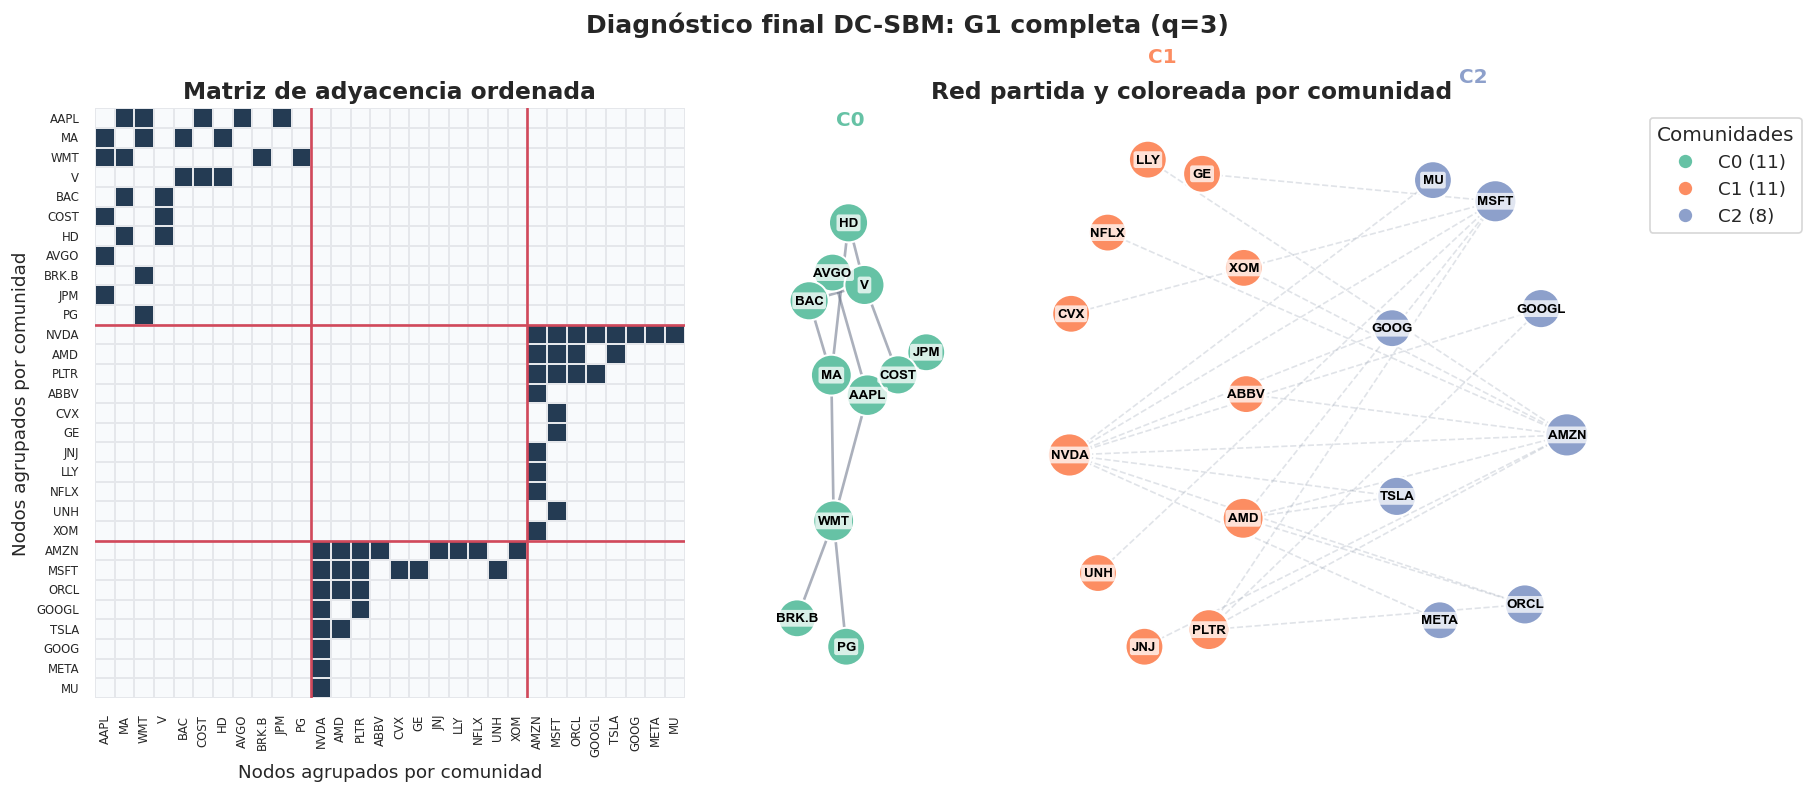

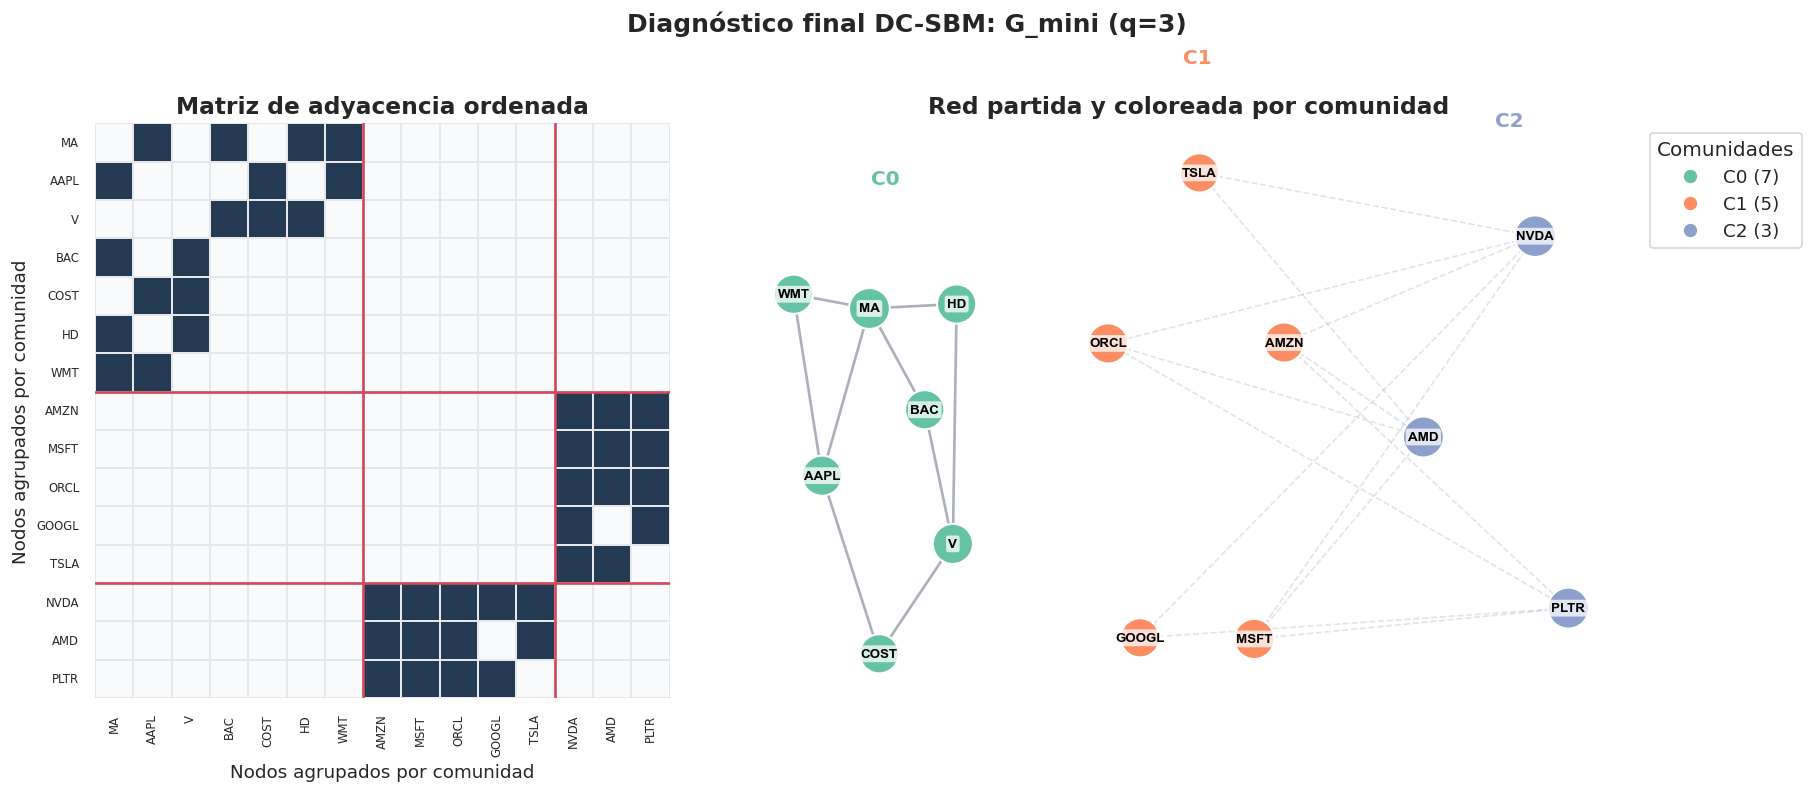

In [13]:
# ============================================================
# 12. Matriz de adyacencia y red partida por comunidades
# ============================================================
def ordered_nodes_by_community(G: nx.Graph, fit: DCSBMFit) -> list[str]:
    ordered = []
    for c in range(fit.q):
        nodes = [node for node in fit.communities[c] if node in G]
        ordered.extend(sorted(nodes, key=lambda node: (-G.degree(node), node)))
    return ordered


def partition_layout(G: nx.Graph, fit: DCSBMFit) -> dict[str, tuple[float, float]]:
    """Ubica cada comunidad en una columna para que la partición se vea explícita."""
    pos = {}
    centers = np.linspace(-1.8 * (fit.q - 1), 1.8 * (fit.q - 1), fit.q) if fit.q > 1 else np.array([0.0])
    for c, center_x in enumerate(centers):
        nodes = [node for node in fit.communities[c] if node in G]
        sub = G.subgraph(nodes)
        if len(nodes) == 1:
            local = {nodes[0]: np.array([0.0, 0.0])}
        else:
            local = nx.spring_layout(sub, seed=RANDOM_SEED + 37 * c, k=0.95)
        spread = 0.85 + 0.08 * np.sqrt(max(1, len(nodes)))
        for node, coords in local.items():
            pos[node] = (center_x + spread * coords[0], spread * coords[1])
    return pos


def plot_adjacency_and_partition(G: nx.Graph, fit: DCSBMFit, title: str, filename: str) -> None:
    nodes = ordered_nodes_by_community(G, fit)
    A = nx.to_numpy_array(G, nodelist=nodes, dtype=int)
    labels = [fit.labels[node] for node in nodes]
    colors = community_color_map(fit)
    node_colors = [colors[fit.labels[node]] for node in G.nodes()]
    node_sizes = [430 + 85 * np.sqrt(G.degree(node)) for node in G.nodes()]
    boundaries = np.cumsum([sum(label == c for label in labels) for c in range(fit.q)])[:-1]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), gridspec_kw={"width_ratios": [1.05, 1.35]}, constrained_layout=True)
    ax_adj, ax_net = axes

    sns.heatmap(
        A,
        ax=ax_adj,
        cmap=sns.color_palette(["#F8FAFC", "#243B53"], as_cmap=True),
        cbar=False,
        square=True,
        linewidths=0.18,
        linecolor="#E5E7EB",
        xticklabels=nodes,
        yticklabels=nodes,
    )
    for boundary in boundaries:
        ax_adj.axhline(boundary, color="#D1495B", linewidth=1.6)
        ax_adj.axvline(boundary, color="#D1495B", linewidth=1.6)
    ax_adj.set_title("Matriz de adyacencia ordenada")
    ax_adj.set_xlabel("Nodos agrupados por comunidad")
    ax_adj.set_ylabel("Nodos agrupados por comunidad")
    ax_adj.tick_params(axis="x", labelrotation=90, labelsize=7)
    ax_adj.tick_params(axis="y", labelsize=7)

    pos = partition_layout(G, fit)
    external_edges = [(u, v) for u, v in G.edges() if fit.labels[u] != fit.labels[v]]
    internal_edges = [(u, v) for u, v in G.edges() if fit.labels[u] == fit.labels[v]]
    nx.draw_networkx_edges(G, pos, edgelist=external_edges, ax=ax_net, edge_color="#A7B0BE", alpha=0.35, width=1.0, style="dashed")
    nx.draw_networkx_edges(G, pos, edgelist=internal_edges, ax=ax_net, edge_color="#667085", alpha=0.55, width=1.6)
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax_net,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors="white",
        linewidths=1.2,
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax_net,
        font_size=8,
        font_weight="bold",
        bbox={"boxstyle": "round,pad=0.18", "fc": "white", "ec": "none", "alpha": 0.74},
    )
    for c, nodes_c in fit.communities.items():
        present = [node for node in nodes_c if node in pos]
        if not present:
            continue
        xs = [pos[node][0] for node in present]
        ys = [pos[node][1] for node in present]
        ax_net.text(
            float(np.mean(xs)),
            float(max(ys) + 0.42),
            f"C{c}",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
            color=colors[c],
        )
    handles = [
        Line2D([0], [0], marker="o", color="w", label=f"C{c} ({len(fit.communities[c])})",
               markerfacecolor=colors[c], markeredgecolor="white", markersize=9)
        for c in range(fit.q)
    ]
    ax_net.legend(handles=handles, title="Comunidades", loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
    ax_net.set_title("Red partida y coloreada por comunidad")
    ax_net.axis("off")

    fig.suptitle(title, fontsize=15, fontweight="bold")
    fig.savefig(OUT_DIR / filename, bbox_inches="tight")
    plt.show()


plot_adjacency_and_partition(
    G1,
    fit_full,
    f"Diagnóstico final DC-SBM: G1 completa (q={fit_full.q})",
    "final_adyacencia_y_red_partida_G1.png",
)
plot_adjacency_and_partition(
    G_mini,
    fit_mini,
    f"Diagnóstico final DC-SBM: G_mini (q={fit_mini.q})",
    "final_adyacencia_y_red_partida_G_mini.png",
)
